# Predicting Online Purchase Intention from Web Session Behaviour

This notebook investigates whether e-commerce browsing sessions can be classified as purchase or non-purchase sessions using supervised machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# A fixed random state is used so that the train/test split and model results are reproducible.
RANDOM_STATE = 42

## Initial data examination

In [2]:
df = pd.read_csv("../data/online_shoppers_intention.csv")
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


The first rows show that each record represents one online shopping session. The target variable is `Revenue`, which shows whether the session ended in a purchase.

The input features describe browsing behaviour, timing and visitor/session information. These include page counts, page durations, rates such as `BounceRates` and `ExitRates`, `PageValues`, `Month`, `VisitorType`, `Weekend` and coded technical features such as `Browser`, `Region` and `TrafficType`.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

The `df.info()` output shows that the dataset has 12,330 rows and 18 columns. All columns have 12,330 non-null values, so there are no missing values shown at this stage.

The data contains a mixture of integers, floats, strings and Boolean values. This means preprocessing will be needed before modelling, especially for categorical variables and Boolean values.

In [4]:
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(125)

There are 125 exact duplicate rows in the dataset. Because these rows match across all columns, including the target variable, they are unlikely to add new information for model training. I inspect them before deciding how to handle them.

In [5]:
duplicate_rows = df[df.duplicated(keep=False)].copy()

duplicate_rows_summary = pd.DataFrame({
    "duplicate_rows_including_originals": [len(duplicate_rows)],
    "duplicate_groups": [duplicate_rows.groupby(list(df.columns)).ngroups],
    "max_repeated_group_size": [
        duplicate_rows.groupby(list(df.columns)).size().max()
    ],
    "purchase_duplicates": [duplicate_rows["Revenue"].sum()],
    "non_purchase_duplicates": [(duplicate_rows["Revenue"] == False).sum()],
    "max_product_duration_in_duplicates": [
        duplicate_rows["ProductRelated_Duration"].max()
    ]
})

duplicate_rows_summary

,duplicate_rows_including_originals,duplicate_groups,max_repeated_group_size,purchase_duplicates,non_purchase_duplicates,max_product_duration_in_duplicates
0,201,76,14,0,201,0.0


The duplicate inspection shows that 201 rows are involved in exact duplicate groups, representing 76 repeated row patterns. The largest repeated pattern appears 14 times. All duplicated rows are non-purchase sessions, and the maximum `ProductRelated_Duration` among them is 0.0.

The UCI dataset description states that the dataset contains 12,330 sessions and was formed so that each session belongs to a different user over a one-year period [11]. This makes exact repeated rows across all features and the target difficult to justify as separate browsing sessions. Since all duplicated rows belong to the majority non-purchase class, keeping them would slightly reinforce the existing class imbalance. Therefore, the duplicates should be dropped.

[11] C. O. Sakar and S. O. Polat, “Online Shoppers Purchasing Intention Dataset,” UCI Machine Learning Repository, 2018. [Online]. Available: https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset

In [6]:
df = df.drop_duplicates().reset_index(drop=True)

df.shape

(12205, 18)

After removing exact duplicates, the dataset contains 12,205 rows. The duplicate removal does not remove any purchase sessions, but it reduces repeated non-purchase records. The target remains imbalanced, so the evaluation strategy still prioritises F1-score, recall, precision and the confusion matrix rather than accuracy alone.

In [7]:
revenue_summary = pd.DataFrame({
    "count": df["Revenue"].value_counts(),
    "percentage": df["Revenue"].value_counts(normalize=True) * 100
})

revenue_summary

,count,percentage
Revenue,,
False,10297,84.367063
True,1908,15.632937


The `Revenue` summary shows a clear class imbalance. Most sessions did not end in a purchase.

This matters because a model could get a decent accuracy by mostly predicting `False`. I will therefore use precision, recall, F1-score and a confusion matrix later, not just accuracy.

Next, I examine the numerical feature distributions to understand the scale and spread of the input variables.

In [8]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,2.124211,2.357804,3.153298,4.073904
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,0.906823,1.710114,2.402340,4.016654
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


The numerical columns have very different ranges. Duration features such as `ProductRelated_Duration` are much larger than rate features such as `BounceRates` and `ExitRates`.

This matters because some candidate models are sensitive to feature scale. I will therefore scale the numerical columns inside the preprocessing pipeline, rather than changing the raw dataset directly.

In [9]:
df.sort_values("ProductRelated_Duration", ascending=False).head(10)[
    ["ProductRelated", "ProductRelated_Duration", "PageValues", "BounceRates", "ExitRates", "Revenue"]
]

,ProductRelated,ProductRelated_Duration,PageValues,BounceRates,ExitRates,Revenue
7983,449,63973.52223,0.000000,0.000764,0.027701,False
5074,705,43171.23338,0.763829,0.004851,0.015431,False
9149,343,29970.46597,0.000000,0.005316,0.028971,False
8695,517,27009.85943,8.403164,0.004385,0.014594,True
8220,584,24844.15620,4.511100,0.002099,0.009347,False
7574,414,23888.81000,1.033757,0.009900,0.027062,False
6599,686,23342.08205,0.150650,0.009853,0.022771,False
6080,486,23050.10414,0.000000,0.000324,0.011249,False
5831,439,21857.04648,11.439233,0.003589,0.012498,False
8883,501,21672.24425,9.131387,0.003965,0.014292,True


The longest `ProductRelated_Duration` values are not exact duplicates. They appear to be unusual but valid browsing sessions rather than repeated logging errors.

The highest value is around 63,974 seconds, or about 17.8 hours. This is extreme, but the rows also have different values for `ProductRelated`, `PageValues`, `BounceRates`, `ExitRates` and `Revenue`, so they are not identical records. I keep these rows because long session durations can occur in web analytics data, especially if a session remains open in the browser.

In [10]:
categorical_cols = ["Month", "VisitorType", "Weekend", "OperatingSystems", "Browser", "Region", "TrafficType"]

categorical_summary = pd.DataFrame({
    "unique_values": df[categorical_cols].nunique(),
    "most_common_value": df[categorical_cols].mode().iloc[0],
    "most_common_count": [df[col].value_counts().iloc[0] for col in categorical_cols]
})

categorical_summary

,unique_values,most_common_value,most_common_count
Month,10,May,3329
VisitorType,3,Returning_Visitor,10431
Weekend,2,False,9346
OperatingSystems,8,2,6541
Browser,13,2,7883
Region,9,1,4714
TrafficType,20,2,3911


This table shows the number of unique values in each categorical or coded feature. `Month`, `VisitorType`, `Weekend`, `OperatingSystems`, `Browser`, `Region` and `TrafficType` are treated as categorical inputs. Although some of them are stored as numbers, they represent category codes rather than measured quantities, so I will one-hot encode them instead of allowing the model to treat larger codes as larger values.

In [11]:
for col in categorical_cols:
    display(
        df[col]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .rename("percentage")
        .to_frame()
    )

,percentage
Month,
May,27.28
Nov,24.43
Mar,15.24
Dec,13.98
Oct,4.50
Sep,3.67
Aug,3.55
Jul,3.54
June,2.34


,percentage
VisitorType,
Returning_Visitor,85.46
New_Visitor,13.87
Other,0.66


,percentage
Weekend,
False,76.58
True,23.42


,percentage
OperatingSystems,
2,53.59
1,20.88
3,20.73
4,3.92
8,0.61
6,0.16
7,0.06
5,0.05


,percentage
Browser,
2,64.59
1,19.89
4,5.99
5,3.81
6,1.43
10,1.34
8,1.11
3,0.86
13,0.46


,percentage
Region,
1,38.62
3,19.49
4,9.59
2,9.24
6,6.56
7,6.21
9,4.14
8,3.53
5,2.61


,percentage
TrafficType,
2,32.04
1,19.57
3,16.49
4,8.73
13,5.96
10,3.69
6,3.63
8,2.81
5,2.13


The categorical columns are not evenly spread. Most sessions are from `Returning_Visitor` users, at 85.46%, while `New_Visitor` users only make up 13.87%. The `Weekend` column is also uneven, with 76.58% of sessions not taking place at the weekend.

Some of the coded categories are heavily concentrated in one or two values. For example, `Browser` value 2 makes up 64.59% of sessions, and `OperatingSystems` value 2 makes up 53.59%. `TrafficType` is less extreme, but values 2, 1 and 3 still account for most sessions.

This means the categorical data is quite skewed. Some categories have plenty of examples for the model to learn from, while others appear very rarely. Because these columns are category labels rather than real measurements, I will encode them as categorical variables in the preprocessing step.

In [12]:
df.groupby("Revenue")[["PageValues", "BounceRates", "ExitRates", "ProductRelated", "ProductRelated_Duration"]].mean()

,PageValues,BounceRates,ExitRates,ProductRelated,ProductRelated_Duration
Revenue,,,,,
False,1.999985,0.023197,0.045526,29.050403,1082.976881
True,27.264518,0.005117,0.019555,48.210168,1876.209615


The grouped averages show clear differences between purchase and non-purchase sessions. Purchase sessions have much higher average `PageValues`, more `ProductRelated` page visits, longer `ProductRelated_Duration`, lower `BounceRates` and lower `ExitRates`.

This suggests that browsing depth and page value may be useful predictors. I will check this later using feature importance and model results.

## Exploratory visualisation

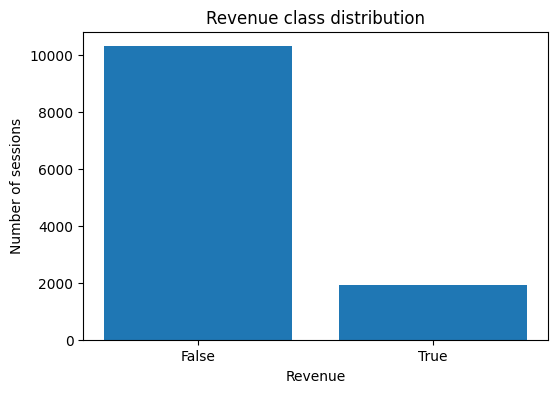

In [13]:
revenue_counts = df["Revenue"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(revenue_counts.index.astype(str), revenue_counts.values)
plt.title("Revenue class distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of sessions")
plt.show()

The chart shows a clear class imbalance. Most sessions did not end in a purchase.

Because of this, accuracy on its own will not be enough. I will also use precision, recall, F1-score and a confusion matrix later.

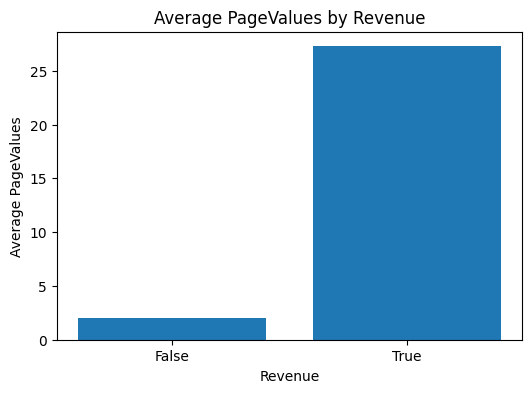

In [14]:
pagevalues_mean = df.groupby("Revenue")["PageValues"].mean()

plt.figure(figsize=(6, 4))
plt.bar(pagevalues_mean.index.astype(str), pagevalues_mean.values)
plt.title("Average PageValues by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Average PageValues")
plt.show()

Purchase sessions have much higher average `PageValues`.

This suggests that `PageValues` may be useful for predicting `Revenue`. I will check this again later when comparing feature importance and model performance.

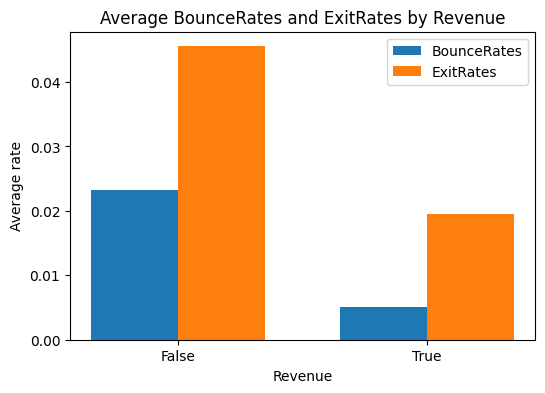

In [15]:
rate_means = df.groupby("Revenue")[["BounceRates", "ExitRates"]].mean()

x = np.arange(len(rate_means.index))
width = 0.35

plt.figure(figsize=(6, 4))
plt.bar(x - width/2, rate_means["BounceRates"], width, label="BounceRates")
plt.bar(x + width/2, rate_means["ExitRates"], width, label="ExitRates")
plt.title("Average BounceRates and ExitRates by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Average rate")
plt.xticks(x, rate_means.index.astype(str))
plt.legend()
plt.show()

Purchase sessions have lower average `BounceRates` and `ExitRates`.

`BounceRates` refers to sessions where a user enters the site and leaves without continuing to other pages. `ExitRates` refers to how often users leave from a particular page. 

Lower values for purchase sessions suggest that users who stay and continue browsing are more likely to buy, so these features may help the models separate purchase and non-purchase sessions.

## Feature and target preparation

In [16]:
# Separate the input features from the target variable
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

Feature data shape: (12205, 17)
Target data shape: (12205,)


I split the dataset into `X` and `y`. `X` contains the input features, and `y` contains the target variable, `Revenue`.

This gives 17 features for each session and one target value to predict.

In [17]:
# Check the target balance before splitting the data
target_balance = pd.DataFrame({
    "count": y.value_counts(),
    "percentage": y.value_counts(normalize=True) * 100
})

target_balance

,count,percentage
Revenue,,
False,10297,84.367063
True,1908,15.632937


The target balance is checked again before splitting the data.

Because the classes are imbalanced, I will use a stratified train-test split so that the training and test sets keep a similar balance of purchase and non-purchase sessions.

In [18]:
# Set up the column groups for preprocessing
categorical_features = [
    "Month",
    "VisitorType",
    "Weekend",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

numerical_features = [col for col in X.columns if col not in categorical_features]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Month', 'VisitorType', 'Weekend', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Numerical features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']


The columns are separated into categorical and numerical features.

The categorical list includes text columns, one Boolean value and coded category columns. The remaining columns are treated as numerical browsing-behaviour features.

`Weekend` is included with the categorical features because it describes the type of session rather than measuring a continuous value. Since it simply indicates whether the visit happened on a weekend or not, it makes sense to treat it like the other categorical variables. Similarly, features such as `OperatingSystems`, `Browser`, `Region`, and `TrafficType` are treated as categorical because their numbers are just labels for different groups, not values with a meaningful order.

In [19]:
# Split the data with an 80/20 train/test split
# Stratify keeps the Revenue balance similar in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training features:", X_train.shape)
print("Test features:", X_test.shape)
print("Training target:", y_train.shape)
print("Test target:", y_test.shape)

Training features: (9764, 17)
Test features: (2441, 17)
Training target: (9764,)
Test target: (2441,)


The data is split into training and test sets. The training set will be used to fit the models, while the test set will be kept back for evaluation.

An 80/20 train-test split is used so that most of the dataset is available for model training, while still keeping a separate unseen test set for final evaluation. The split uses `stratify=y` because the target variable is imbalanced, with only about 15.6% of sessions resulting in a purchase. Stratification keeps this class balance similar in both the training and test sets, which makes the evaluation fairer and reduces the chance that the minority purchase class is under-represented in either split.

In [20]:
# Check that the class balance is similar after the split
split_balance = pd.DataFrame({
    "train_percentage": y_train.value_counts(normalize=True) * 100,
    "test_percentage": y_test.value_counts(normalize=True) * 100
})

split_balance

,train_percentage,test_percentage
Revenue,,
False,84.371159,84.350676
True,15.628841,15.649324


`split_balance` confirms that stratification successfully maintained consistent class proportions between the training and testing sets.

In [21]:
# Save the original-feature train/test split for later comparison
X_train.to_csv("../outputs/X_train_original_features.csv", index=False)
X_test.to_csv("../outputs/X_test_original_features.csv", index=False)
y_train.to_csv("../outputs/y_train_original_features.csv", index=False)
y_test.to_csv("../outputs/y_test_original_features.csv", index=False)

# Preprocessing setup

In [22]:
# Scale numbers and one-hot encode categories
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ],
    sparse_threshold=0
)

print(preprocessor)

ColumnTransformer(sparse_threshold=0,
                  transformers=[('num', StandardScaler(),
                                 ['Administrative', 'Administrative_Duration',
                                  'Informational', 'Informational_Duration',
                                  'ProductRelated', 'ProductRelated_Duration',
                                  'BounceRates', 'ExitRates', 'PageValues',
                                  'SpecialDay']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Month', 'VisitorType', 'Weekend',
                                  'OperatingSystems', 'Browser', 'Region',
                                  'TrafficType'])])


The preprocessor applies different steps to different column types.

The numerical columns are scaled with `StandardScaler`, and the categorical columns are converted with `OneHotEncoder`. This prepares the data for models that need numerical input.

## Feature Selection

The heatmap shows the correlation between the numerical features. Red areas show positive correlations, blue areas show negative correlations, and the diagonal is always strongest because each feature is perfectly correlated with itself.

The clearest relationship with `Revenue` is the positive correlation with `PageValues`. `ExitRates` and `BounceRates` move in the opposite direction, which suggests that sessions with higher exit or bounce behaviour are less likely to end in a purchase. This is only an initial linear check, so it is used as a simple filter view rather than as the final feature selection method.

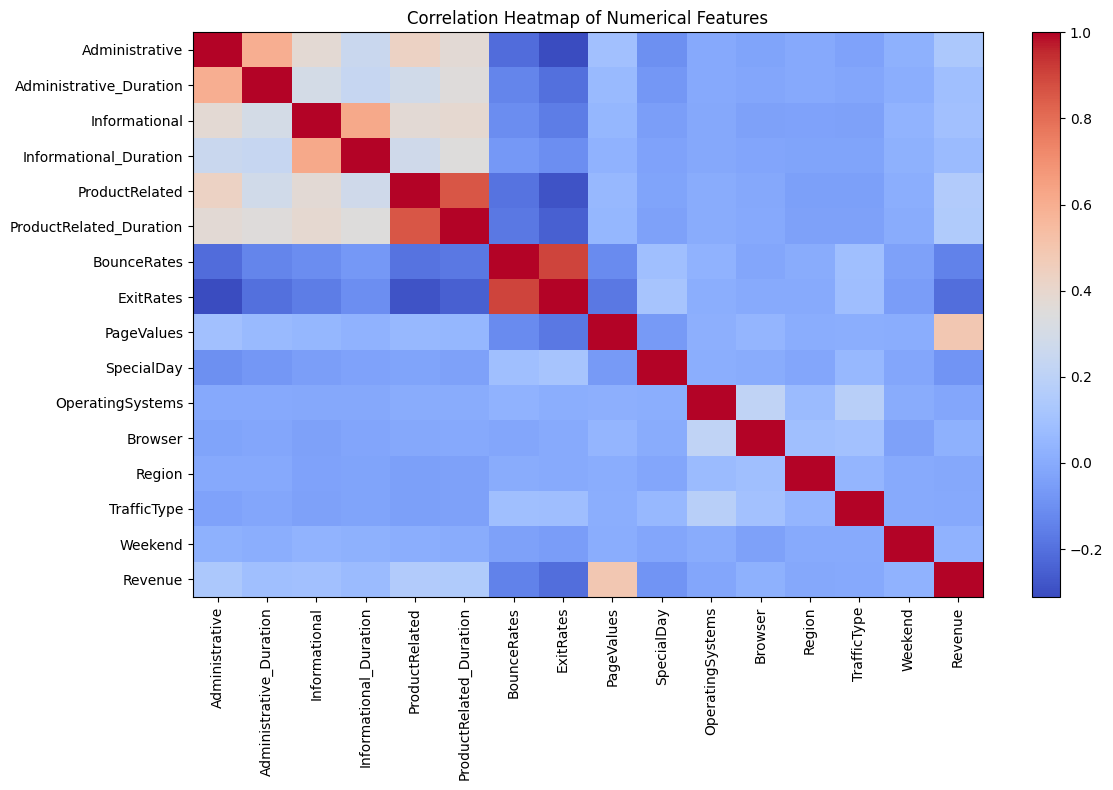

In [23]:
# Create a correlation matrix for the numerical columns
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

The correlation check reinforces that `PageValues` has the strongest positive relationship with `Revenue`. `ProductRelated` and `ProductRelated_Duration` are also positively related to purchases.

`ExitRates` and `BounceRates` have negative correlations with `Revenue`. This is consistent with the idea that sessions where users leave quickly are less likely to end in a purchase, although correlation only shows association rather than causation.

Some features, such as `Administrative`, `Informational`, `SpecialDay` and `Informational_Duration`, show weaker direct correlations with `Revenue`. These features may still be useful in combination with others, but their individual linear relationship with the target is weaker. Correlation is therefore used as a simple filter check, while mutual information is used next as a broader feature selection method.

## Feature Selection with Mutual Information

Mutual information is used as an initial filter-based feature selection check. It is fitted only on the training data to avoid using information from the test set during model development. The purpose is not to choose the final model automatically, but to see which processed features carry the strongest individual signal for `Revenue`.

In [24]:
from sklearn.base import clone
from sklearn.feature_selection import mutual_info_classif

# Fit a copy of the preprocessor on the training data only.
# This avoids using the test set when calculating feature selection scores.
mi_preprocessor = clone(preprocessor)

X_train_processed = mi_preprocessor.fit_transform(X_train)
processed_feature_names = mi_preprocessor.get_feature_names_out()

# Mutual information gives a filter-based score for each processed feature.
# The random_state keeps the score calculation reproducible.
mi_scores = mutual_info_classif(
    X_train_processed,
    y_train,
    random_state=RANDOM_STATE
)

mi_scores_df = (
    pd.DataFrame({
        "feature": processed_feature_names,
        "mutual_information": mi_scores
    })
    .sort_values(by="mutual_information", ascending=False)
    .reset_index(drop=True)
)

mi_scores_df.head(15)

,feature,mutual_information
0,num__PageValues,0.163820
1,num__ExitRates,0.037809
2,num__ProductRelated_Duration,0.032262
3,num__BounceRates,0.020914
4,num__ProductRelated,0.019765
5,num__Administrative,0.017184
6,cat__Month_Nov,0.013419
7,num__SpecialDay,0.009886
8,cat__TrafficType_15,0.009080
9,num__Administrative_Duration,0.008649


The mutual information scores suggest that `PageValues` is by far the strongest individual feature, with a score of 0.163820. There is a clear drop after this. The next highest features are `ExitRates` at 0.037809, `ProductRelated_Duration` at 0.032262 and `BounceRates` at 0.020914.

This makes sense for this dataset. `PageValues` is linked to the estimated value of pages visited before a transaction, so it is closely connected to purchase behaviour. The other high-ranking features are also mainly about how users behaved during the session, such as whether they stayed on product pages, left quickly, or exited the site.

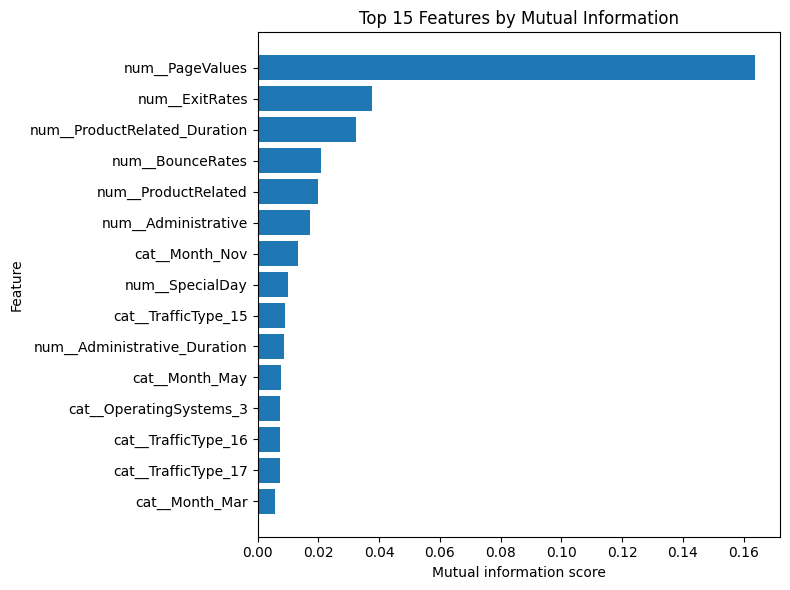

In [25]:
top_mi_features = mi_scores_df.head(15).sort_values("mutual_information")

plt.figure(figsize=(8, 6))
plt.barh(top_mi_features["feature"], top_mi_features["mutual_information"])
plt.xlabel("Mutual information score")
plt.ylabel("Feature")
plt.title("Top 15 Features by Mutual Information")
plt.tight_layout()
plt.show()

The chart makes the same pattern easier to see. `PageValues` stands out clearly, while the rest of the features have much smaller mutual information scores.

Most of the top features are numerical browsing-behaviour features, including `ExitRates`, `ProductRelated_Duration`, `BounceRates`, `ProductRelated`, `Administrative_Duration` and `Administrative`. A few one-hot encoded categorical features also appear, such as `Month_Nov`, `VisitorType_New_Visitor`, `Month_May`, `OperatingSystems_5`, `Region_1` and `Month_Oct`.

This suggests that the strongest signal comes from what the visitor actually did during the session. Timing and visitor type still seem useful, but they are not as strong as the direct behavioural features.

In [26]:
from sklearn.feature_selection import SelectKBest

# Use a wrapper so mutual information is reproducible inside SelectKBest.
def reproducible_mutual_info(X, y):
    return mutual_info_classif(
        X,
        y,
        random_state=RANDOM_STATE
    )

# Use the top 15 processed features from mutual information.
# This selector is placed inside the pipeline so it is fitted only on the
# training folds during cross-validation.
TOP_K_FEATURES = 15

selected_feature_results = []
selected_feature_pipelines = {}

selected_feature_models = {
    "Logistic Regression selected features": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Support Vector Machine selected features": SVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Hist Gradient Boosting selected features": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "MLPClassifier selected features": MLPClassifier(
        max_iter=1000,
        random_state=RANDOM_STATE
    )
}

for model_name, model in selected_feature_models.items():
    selected_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("feature_selection", SelectKBest(
            score_func=reproducible_mutual_info,
            k=TOP_K_FEATURES
        )),
        ("model", model)
    ])

    selected_pipeline.fit(X_train, y_train)
    y_pred_selected = selected_pipeline.predict(X_test)

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred_selected),
        "precision": precision_score(y_test, y_pred_selected, pos_label=True, zero_division=0),
        "recall": recall_score(y_test, y_pred_selected, pos_label=True, zero_division=0),
        "f1": f1_score(y_test, y_pred_selected, pos_label=True, zero_division=0)
    }

    selected_feature_results.append(results)
    selected_feature_pipelines[model_name] = selected_pipeline

selected_feature_results_df = pd.DataFrame(selected_feature_results)
selected_feature_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
3,MLPClassifier selected features,0.902909,0.725857,0.609948,0.662873
1,Support Vector Machine selected features,0.870545,0.560219,0.803665,0.660215
2,Hist Gradient Boosting selected features,0.899631,0.704478,0.617801,0.658298
0,Logistic Regression selected features,0.851290,0.516351,0.785340,0.623053


The selected-feature models give mixed results. `MLPClassifier` has the highest F1-score on this selected feature set, at 0.662873. `Support Vector Machine` is close behind, with an F1-score of 0.660215, while `Hist Gradient Boosting` achieves 0.658298.

`Support Vector Machine` has the highest recall, at 0.803665, meaning it identifies the largest share of purchase sessions. However, its precision is lower, at 0.560219, so it is more likely to classify non-purchase sessions as purchases. `Logistic Regression` follows a similar pattern, with recall of 0.785340 and precision of 0.516351.

At this stage, the selected-feature models are useful as a simplification experiment. The experiment shows that a reduced set of features can produce reasonable performance. I do not choose the final feature set from this result alone, because the selected-feature models still need to be compared with the full-feature modelling results in the next stage.

In [27]:
# Inspect the fitted selector from one selected-feature pipeline.
# The selected feature list should be the same because the selector uses the same training data.
selected_pipeline = selected_feature_pipelines["Hist Gradient Boosting selected features"]

processed_feature_names = (
    selected_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

selected_mask = (
    selected_pipeline
    .named_steps["feature_selection"]
    .get_support()
)

selected_features_df = pd.DataFrame({
    "selected_feature": processed_feature_names[selected_mask]
})

selected_features_df

,selected_feature
0,num__Administrative
1,num__Administrative_Duration
2,num__ProductRelated
3,num__ProductRelated_Duration
4,num__BounceRates
5,num__ExitRates
6,num__PageValues
7,num__SpecialDay
8,cat__Month_Mar
9,cat__Month_May


The selected feature list confirms that `SelectKBest` kept a mixture of numerical behavioural features and one-hot encoded categorical features. The selected numerical features include page counts, durations, `BounceRates`, `ExitRates`, `PageValues` and `SpecialDay`.

The selected categorical features are `Month_Mar`, `Month_May`, `Month_Nov`, `OperatingSystems_3`, `TrafficType_15`, `TrafficType_16` and `TrafficType_17`. This is useful because it shows exactly what the selected-feature experiment used after preprocessing. Most of the selected features are still direct session-behaviour variables, but some timing and traffic-related categories also appear to carry useful signal for predicting `Revenue`.

## Candidate Machine Learning Models

This project uses supervised machine learning because the dataset contains labelled examples. Each session has a known target value, `Revenue`, showing whether the session ended in a purchase. The task is therefore a binary classification problem.

Several candidate classification algorithms are tested so that different modelling approaches can be compared. `Logistic Regression` is included as an interpretable linear baseline. `Decision Tree` and `Random Forest` are included because tree-based models can capture non-linear relationships and interactions between features. `Gradient Boosting` and `Hist Gradient Boosting` are included because boosting methods often perform well on structured tabular datasets. `Support Vector Machine` is included because it can work well for classification after scaling. `K-Nearest Neighbours` is included as a distance-based baseline, while `MLPClassifier` is included as a neural network comparison.

This gives a mix of linear, tree-based, ensemble, distance-based, kernel-based and neural network methods. Comparing these models helps avoid choosing a final model based on one modelling assumption only.

## Baseline model comparison

Several baseline classification models are tested using the same train-test split and preprocessing steps.

Because the target is imbalanced, accuracy could be misleading. Accuracy is still recorded, but the comparison focuses more on F1-score, recall, precision and the confusion matrix.

The baseline models are first trained using default or lightly adjusted settings. This gives an initial comparison before tuning. For models that support it cleanly, `class_weight="balanced"` is used because the target variable is imbalanced and only about 15.6% of sessions resulted in a purchase. The main comparison metric is F1-score, because it balances precision and recall and is more informative than accuracy alone for this imbalanced classification task.

In [28]:
# Baseline models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "K-Nearest Neighbours": KNeighborsClassifier(),
    "Support Vector Machine": SVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "MLPClassifier": MLPClassifier(
        max_iter=500,
        random_state=RANDOM_STATE
    )
}

`class_weight="balanced"` is used for models where it works well, such as Logistic Regression, Decision Tree, Random Forest, and SVM. It helps the model pay more attention to the smaller purchase class by giving it extra weight. Since not all models handle this setting in the same way, class imbalance is also addressed through stratified splitting and by focusing on F1-score, precision, and recall instead of accuracy alone.

In [29]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    # Put the same preprocessing in front of every model
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train on the training data only
    pipeline.fit(X_train, y_train)
    
    # Predict on the test data
    y_pred = pipeline.predict(X_test)
    
    # Store the main scores
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label=True, zero_division=0),
        "recall": recall_score(y_test, y_pred, pos_label=True, zero_division=0),
        "f1": f1_score(y_test, y_pred, pos_label=True, zero_division=0)
    }
    
    print("\n" + model_name)
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    return results, pipeline

In [30]:
baseline_results = []
trained_pipelines = {}

for model_name, model in models.items():
    results, pipeline = evaluate_model(
        model_name,
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )
    
    baseline_results.append(results)
    trained_pipelines[model_name] = pipeline


Logistic Regression
Confusion matrix:
[[1761  298]
 [  78  304]]

Classification report:
              precision    recall  f1-score   support

       False       0.96      0.86      0.90      2059
        True       0.50      0.80      0.62       382

    accuracy                           0.85      2441
   macro avg       0.73      0.83      0.76      2441
weighted avg       0.89      0.85      0.86      2441


Decision Tree
Confusion matrix:
[[1897  162]
 [ 190  192]]

Classification report:
              precision    recall  f1-score   support

       False       0.91      0.92      0.92      2059
        True       0.54      0.50      0.52       382

    accuracy                           0.86      2441
   macro avg       0.73      0.71      0.72      2441
weighted avg       0.85      0.86      0.85      2441


Random Forest
Confusion matrix:
[[1993   66]
 [ 192  190]]

Classification report:
              precision    recall  f1-score   support

       False       0.91      0.97

/Users/garyzolty/Desktop/University/AML/aml-online-shoppers/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [31]:
baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
6,Hist Gradient Boosting,0.904957,0.727273,0.628272,0.674157
5,Gradient Boosting,0.901680,0.708824,0.630890,0.667590
4,Support Vector Machine,0.868906,0.558935,0.769634,0.647577
0,Logistic Regression,0.845965,0.504983,0.795812,0.617886
7,MLPClassifier,0.878329,0.617729,0.583770,0.600269
2,Random Forest,0.894306,0.742188,0.497382,0.595611
1,Decision Tree,0.855797,0.542373,0.502618,0.521739
3,K-Nearest Neighbours,0.873413,0.662222,0.390052,0.490939


The baseline comparison shows that the models behave quite differently on the purchase class.

`Hist Gradient Boosting` has the best F1-score for the `True` class, at about `0.67`, and the highest accuracy at about `0.90`. Its precision is about `0.73` and recall is about `0.63`, so it gives the strongest overall balance in the baseline comparison.

`Gradient Boosting` performs almost the same as `Hist Gradient Boosting`, with accuracy of about `0.90` and an F1-score of about `0.67` for the `True` class. Its precision is about `0.71` and recall is about `0.63`. This shows that the standard boosting model is also a strong baseline, but in this test it is slightly behind `Hist Gradient Boosting`.

`Support Vector Machine` also has strong recall, at about `0.77`, and a better F1-score than `Logistic Regression`, at about `0.65`. This makes it a useful comparison model, although its precision is still lower than the boosting models.

`Logistic Regression` has the highest recall for the purchase class, at about `0.80`, which means it finds the most actual purchase sessions. However, its precision is much lower, at about `0.50`, so it also makes more false purchase predictions.

`Random Forest` has the highest precision for the purchase class, at about `0.74`, but recall is much lower at about `0.50`. This means it gives fewer false purchase predictions, but misses about half of the real purchases.

`Decision Tree` and `K-Nearest Neighbours` are weaker overall on F1-score. `MLPClassifier` performs reasonably, but it gives a convergence warning, so it needs more tuning before being judged properly.


In [32]:
# Save baseline results so they can be reused later in the notebook
baseline_results_df.to_csv(
    "../outputs/baseline_results_original_features.csv",
    index=False
)

Based on this first comparison, `Hist Gradient Boosting`, `Gradient Boosting`, `Support Vector Machine`, `Logistic Regression` and `Random Forest` look most worth continuing with. `Hist Gradient Boosting` has the best F1-score, `Gradient Boosting` gives a very similar result, `Logistic Regression` and `Support Vector Machine` have strong recall, and `Random Forest` has strong precision.

`MLPClassifier` gives a reasonable result. Although its baseline result does not outperform the strongest models and it produces a convergence warning, it is still useful as a comparison because neural networks are a different model family. This allows the project to compare linear, kernel-based, tree-based ensemble and neural network approaches.

## Feature Importance Analysis

Feature importance is checked before tuning to get an initial model-based view of which inputs are most influential.

This check uses `Gradient Boosting` because it is one of the strongest baseline models and provides a straightforward built-in feature importance measure. The result is used as an exploratory check only, not as the final explanation of the selected model.

Features are not removed automatically just because they have lower importance, as weaker individual features may still help when combined with others.

In [33]:
# Get the trained Gradient Boosting pipeline
gb_pipeline = trained_pipelines["Gradient Boosting"]

# Get the fitted model and the fitted preprocessor
gb_model = gb_pipeline.named_steps["model"]
gb_preprocessor = gb_pipeline.named_steps["preprocessor"]

# Get the feature names after preprocessing
feature_names = gb_preprocessor.get_feature_names_out()

# Match each feature name with its importance score
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": gb_model.feature_importances_
})

feature_importance.sort_values(by="importance", ascending=False).head(10)

,feature,importance
8,num__PageValues,0.746017
17,cat__Month_Nov,0.044649
6,num__BounceRates,0.043008
5,num__ProductRelated_Duration,0.034506
0,num__Administrative,0.030777
7,num__ExitRates,0.025386
1,num__Administrative_Duration,0.014230
4,num__ProductRelated,0.013252
16,cat__Month_May,0.008298
22,cat__VisitorType_Returning_Visitor,0.006751


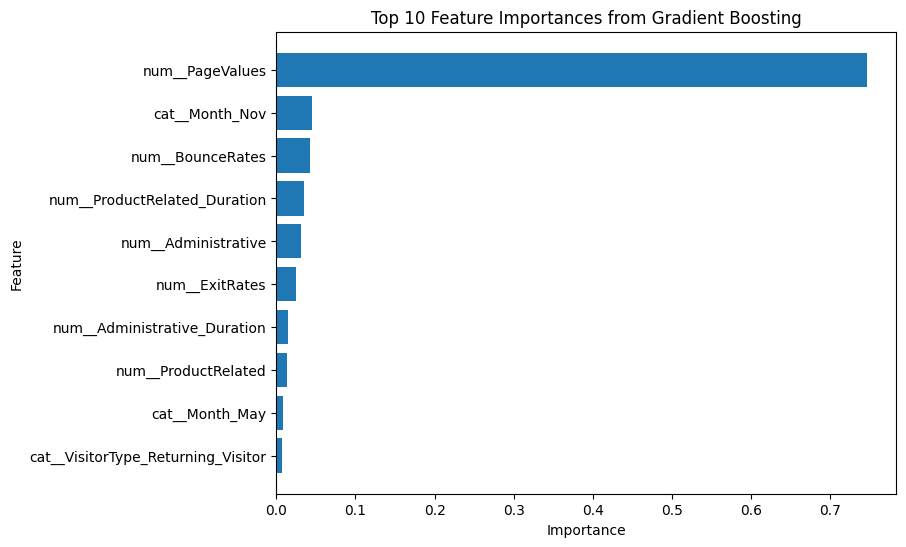

In [34]:
top_features = feature_importance.sort_values(by="importance", ascending=False).head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.title("Top 10 Feature Importances from Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The feature importance plot shows that `PageValues` is by far the strongest feature in the Gradient Boosting model.

After `PageValues`, the next most important features are `BounceRates`, `Month_Nov`, `Administrative`, `ExitRates`, `ProductRelated_Duration` and `ProductRelated`. This partly supports the earlier analysis, because `BounceRates`, `ExitRates` and product-related activity all relate to how users move through the website.

`Month_Nov` being important may make sense because online shopping behaviour can change by month, especially around seasonal shopping periods. `Administrative` is also useful to note because it suggests that non-product browsing activity may still contain some signal.

This is only an exploratory importance check from one strong baseline model. The final model explanation is checked later using permutation importance on the leading tuned contenders.

## Diagnostic Check: Model Dependence on PageValues

The feature importance results showed that `PageValues` was the strongest feature in the `Gradient Boosting` model. This may be useful for prediction, but it also means the model may depend heavily on one input.

To check this more carefully, the same `Gradient Boosting` setup is compared with and without `PageValues` using cross-validation on the training data only. This keeps the test set separate while checking how much the model depends on this feature.

In [35]:
from sklearn.model_selection import cross_validate, StratifiedKFold

# Set up cross-validation on the training data only
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Features with and without PageValues
X_train_with_pagevalues = X_train.copy()
X_train_without_pagevalues = X_train.drop(columns=["PageValues"])

# Update numerical feature list for the reduced feature set
numerical_features_without_pagevalues = [
    col for col in numerical_features if col != "PageValues"
]

# Preprocessor for the full feature set
preprocessor_with_pagevalues = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Preprocessor for the feature set without PageValues
preprocessor_without_pagevalues = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features_without_pagevalues),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Same model used in both experiments
gb_with_pagevalues_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_with_pagevalues),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

gb_without_pagevalues_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_without_pagevalues),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

# Metrics to compare
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

# Cross-validation with PageValues
cv_with_pagevalues = cross_validate(
    gb_with_pagevalues_pipeline,
    X_train_with_pagevalues,
    y_train,
    cv=cv,
    scoring=scoring
)

# Cross-validation without PageValues
cv_without_pagevalues = cross_validate(
    gb_without_pagevalues_pipeline,
    X_train_without_pagevalues,
    y_train,
    cv=cv,
    scoring=scoring
)

# Build a comparison table
pagevalues_cv_comparison = pd.DataFrame({
    "With PageValues": [
        cv_with_pagevalues["test_accuracy"].mean(),
        cv_with_pagevalues["test_precision"].mean(),
        cv_with_pagevalues["test_recall"].mean(),
        cv_with_pagevalues["test_f1"].mean()
    ],
    "Without PageValues": [
        cv_without_pagevalues["test_accuracy"].mean(),
        cv_without_pagevalues["test_precision"].mean(),
        cv_without_pagevalues["test_recall"].mean(),
        cv_without_pagevalues["test_f1"].mean()
    ]
}, index=["accuracy", "precision", "recall", "f1"])

pagevalues_cv_comparison["Difference"] = (
    pagevalues_cv_comparison["Without PageValues"]
    - pagevalues_cv_comparison["With PageValues"]
)

pagevalues_cv_comparison

,With PageValues,Without PageValues,Difference
accuracy,0.902192,0.845862,-0.056330
precision,0.728340,0.550415,-0.177925
recall,0.597634,0.079310,-0.518324
f1,0.656280,0.138221,-0.518059


The cross-validation results show that removing `PageValues` causes a major drop in performance for the purchase class. With `PageValues`, the `Gradient Boosting` model achieved an average F1-score of 0.656280 and recall of 0.597634. Without `PageValues`, the F1-score dropped to 0.138221 and recall dropped to 0.079310.

Precision also fell from 0.728340 to 0.550415, while accuracy dropped from 0.902192 to 0.845862. The accuracy drop is much smaller than the recall and F1-score drops, which shows why accuracy is not enough on its own for this imbalanced dataset. The model can still appear reasonably accurate while performing very poorly on the minority purchase class.

This diagnostic check suggests that `PageValues` carries very important predictive information for this dataset. `PageValues` is therefore kept in the modelling pipeline, but the final report should mention that the model depends heavily on this feature. This is a limitation because `PageValues` may be closely linked to purchase behaviour and may not always be available at the intended prediction point in a real business setting.

## Model Tuning and Refinement

After comparing the baseline models, the strongest or most informative candidates are tuned. Tuning is focused on models that either achieved strong baseline F1-score or showed a useful precision-recall trade-off.

`Hist Gradient Boosting` and `Gradient Boosting` are tuned because they had the strongest baseline F1-scores. `Support Vector Machine` and `Logistic Regression` are tuned because they achieved strong recall on the purchase class. `Random Forest` is also considered because it had the strongest precision, although its recall was weaker. `MLPClassifier` is tuned as a neural network comparison, and because its baseline run produced a convergence warning.

`RandomizedSearchCV` is used for tuning rather than a full grid search. This is a practical choice because several models and parameter combinations are being tested, and random search can explore useful configurations with lower runtime than testing every possible combination. The searches use 5-fold cross-validation on the training data and `scoring="f1"` so that each configuration is compared using a metric that reflects both precision and recall.

## Tuning Gradient Boosting

I will tune `Gradient Boosting` first because it has the best baseline F1-score for the purchase class. I will use a small parameter search rather than a very large grid, so that the tuning process will be manageable and can run locally. The search will use F1-score as the main scoring metric for the reasons explained above.

In [36]:
from sklearn.model_selection import RandomizedSearchCV

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

"""
I chose these parameters because they control the main ways a Gradient Boosting model can become more or less complex. 
`n_estimators` and `learning_rate` control how many boosting stages are used and how strongly each stage affects the final model. 
`max_depth` controls how complex each individual tree can be, while `min_samples_leaf` can help reduce overfitting by stopping leaves from
becoming too small. I used a small search space first so that tuning stayed manageable and could be expanded later if needed [2].
[2] Scikit-learn developers, “GradientBoostingClassifier,” Scikit-learn documentation. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html. [Accessed: 3-Jun-2026].
"""
gb_param_grid = {
    # Number of boosting stages to build
    "model__n_estimators": [100, 200],
    # Controls how strongly each new tree contributes
    # Scikit-learn notes a trade-off between learning_rate and n_estimators [2]
    "model__learning_rate": [0.05, 0.1],
    # Controls the depth of each individual tree
    "model__max_depth": [2, 3],
    # A slightly higher value can smooth the model and reduce overfitting
    "model__min_samples_leaf": [1, 2]
}

# RandomizedSearchCV tests a limited number of parameter combinations using cross-validation, rather than exhaustively testing every combination [3].
# [3] Scikit-learn developers, “RandomizedSearchCV,” Scikit-learn documentation. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html. [Accessed: 3-Jun-2026].
gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_param_grid,
    n_iter=6,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Fit the search on the training data only
gb_search.fit(X_train, y_train)

print("Best parameters:")
print(gb_search.best_params_)

print("Best cross-validation F1-score:")
print(gb_search.best_score_)

Best parameters:
{'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_depth': 3, 'model__learning_rate': 0.05}
Best cross-validation F1-score:
0.6603656495665394


In [37]:
gb_tuned_pred = gb_search.predict(X_test)

gb_tuned_results = {
    "model": "Tuned Gradient Boosting",
    "accuracy": accuracy_score(y_test, gb_tuned_pred),
    "precision": precision_score(y_test, gb_tuned_pred, pos_label=True, zero_division=0),
    "recall": recall_score(y_test, gb_tuned_pred, pos_label=True, zero_division=0),
    "f1": f1_score(y_test, gb_tuned_pred, pos_label=True, zero_division=0)
}

print("\nTuned Gradient Boosting")
print("Confusion matrix:")
print(confusion_matrix(y_test, gb_tuned_pred))

print("\nClassification report:")
print(classification_report(y_test, gb_tuned_pred, zero_division=0))

gb_tuned_results


Tuned Gradient Boosting
Confusion matrix:
[[1964   95]
 [ 139  243]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2059
        True       0.72      0.64      0.68       382

    accuracy                           0.90      2441
   macro avg       0.83      0.79      0.81      2441
weighted avg       0.90      0.90      0.90      2441



{'model': 'Tuned Gradient Boosting',
 'accuracy': 0.9041376485047112,
 'precision': 0.7189349112426036,
 'recall': 0.6361256544502618,
 'f1': 0.675}

The tuned `Gradient Boosting` model selected 200 boosting stages, a minimum leaf size of 3, a maximum tree depth of 3 and a learning rate of 0.05. Compared with the baseline model, this uses more boosting stages but a lower learning rate, so the model learns in smaller steps.

The tuned model gave a small improvement over the baseline `Gradient Boosting` result. The baseline model had an F1-score of 0.667590 for the `Revenue=True` class, while the tuned model achieved about 0.68. Recall increased slightly from 0.630890 to 0.64, meaning it correctly identified 243 out of 382 purchase sessions. Precision also increased slightly from 0.708824 to 0.72.

The confusion matrix shows 1964 true negatives, 95 false positives, 139 false negatives and 243 true positives. Overall, this tuning step produced a modest improvement, mainly by identifying two more purchase sessions while keeping precision slightly higher than the baseline.

## Tuning Hist Gradient Boosting

`Hist Gradient Boosting` was tuned next because its baseline result was very close to the standard `Gradient Boosting` model. Since it uses a histogram-based version of gradient boosting, it may be efficient to tune while still keeping similar predictive behaviour. A small parameter search was used first so that the tuning process stayed manageable.

In [38]:
hgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))
])

"""
I tuned Hist Gradient Boosting after the standard Gradient Boosting model because its baseline result was very similar.
I chose a small set of parameters that control the main parts of the model: how many boosting iterations are used,
how strongly each iteration contributes, how complex the trees can become, and whether regularisation is applied.

`max_iter` controls the number of boosting iterations, `learning_rate` controls the contribution of each boosting step,
`max_leaf_nodes` limits the size of each tree, and `l2_regularization` penalises more complex leaf values [4].

[4] Scikit-learn developers, “HistGradientBoostingClassifier,” Scikit-learn documentation. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html. [Accessed: 3-Jun-2026].
"""
hgb_param_grid = {
    # Number of boosting iterations (similar to the number of trees for binary classification)
    "model__max_iter": [100, 200],
    # Lower learning rates make the model learn more gradually
    "model__learning_rate": [0.05, 0.1],
    # Controls tree complexity by limiting the number of leaf nodes in each tree
    "model__max_leaf_nodes": [15, 31],
    # Adds regularisation. 0 for default, 0.1 adds a small penalty
    "model__l2_regularization": [0, 0.1]
}

hgb_search = RandomizedSearchCV(
    estimator=hgb_pipeline,
    param_distributions=hgb_param_grid,
    n_iter=6,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

hgb_search.fit(X_train, y_train)

print("Best parameters:")
print(hgb_search.best_params_)

print("Best cross-validation F1-score:")
print(hgb_search.best_score_)

Best parameters:
{'model__max_leaf_nodes': 15, 'model__max_iter': 100, 'model__learning_rate': 0.05, 'model__l2_regularization': 0}
Best cross-validation F1-score:
0.6520259415075544


In [39]:
hgb_tuned_pred = hgb_search.predict(X_test)

hgb_tuned_results = {
    "model": "Tuned Hist Gradient Boosting",
    "accuracy": accuracy_score(y_test, hgb_tuned_pred),
    "precision": precision_score(y_test, hgb_tuned_pred, pos_label=True, zero_division=0),
    "recall": recall_score(y_test, hgb_tuned_pred, pos_label=True, zero_division=0),
    "f1": f1_score(y_test, hgb_tuned_pred, pos_label=True, zero_division=0)
}

print("\nTuned Hist Gradient Boosting")
print("Confusion matrix:")
print(confusion_matrix(y_test, hgb_tuned_pred))

print("\nClassification report:")
print(classification_report(y_test, hgb_tuned_pred, zero_division=0))

hgb_tuned_results


Tuned Hist Gradient Boosting
Confusion matrix:
[[1966   93]
 [ 144  238]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2059
        True       0.72      0.62      0.67       382

    accuracy                           0.90      2441
   macro avg       0.83      0.79      0.81      2441
weighted avg       0.90      0.90      0.90      2441



{'model': 'Tuned Hist Gradient Boosting',
 'accuracy': 0.9029086439983613,
 'precision': 0.7190332326283988,
 'recall': 0.6230366492146597,
 'f1': 0.667601683029453}

In [40]:
tuned_results = [
    gb_tuned_results,
    hgb_tuned_results
]

The tuned `Hist Gradient Boosting` model selected a learning rate of 0.05, 100 boosting iterations, 15 maximum leaf nodes and no L2 regularisation. The lower learning rate means the model learns more gradually, while the smaller number of leaf nodes keeps the individual trees more controlled.

This tuning step did not improve the model compared with the baseline `Hist Gradient Boosting` result. The baseline model had an F1-score of 0.674157 for the `Revenue=True` class, while the tuned model achieved about 0.67. Precision decreased slightly from 0.727273 to 0.72, and recall decreased slightly from 0.628272 to 0.62.

The confusion matrix shows that the tuned model correctly identified 238 purchase sessions and missed 144. It also made 93 false purchase predictions. Compared with the baseline version, this is slightly weaker because it finds fewer purchase sessions and creates slightly more false positives.

`Tuned Hist Gradient Boosting` is still a strong model, but this tuning run does not improve on its baseline result. `Gradient Boosting` is currently the strongest tuned model so far, with a slightly higher F1-score for the purchase class. The next step is to tune `Support Vector Machine`, which comes from a different model family, to check whether a kernel-based model can produce a better recall or F1-score trade-off.


In [41]:
def evaluate_tuned_model(search, model_name, X_test, y_test):
    y_pred = search.predict(X_test)
    
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label=True, zero_division=0),
        "recall": recall_score(y_test, y_pred, pos_label=True, zero_division=0),
        "f1": f1_score(y_test, y_pred, pos_label=True, zero_division=0)
    }
    
    print("\n" + model_name)
    print("Best parameters:")
    print(search.best_params_)
    print("\nBest CV F1-score:")
    print(search.best_score_)
    
    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    return results

## Tuning Support Vector Machine

`Support Vector Machine` is tuned because it was one of the stronger baseline models for the purchase class. It achieved high recall and a stronger F1-score than `Logistic Regression`, although its precision was lower than the boosting models. The aim of tuning is therefore to check whether SVM can keep its useful recall while improving the overall F1-score.

The tuning search compares a `linear` kernel with an `rbf` kernel. Scikit-learn explains that SVC models try to find a separating hyperplane by maximising the margin between classes, with `C` controlling the amount of regularisation and tolerance for misclassification [7]. A linear kernel is included because it tests whether a simpler boundary is sufficient. An `rbf` kernel is also included because it can model non-linear class boundaries and is the default SVM kernel in scikit-learn [7].

The search tunes `C` for both kernels and tunes `gamma` only for the `rbf` kernel. This is because `gamma` is ignored for the linear kernel, but for non-linear kernels it controls the influence of individual training samples on the decision boundary [7]. `class_weight` is also included because the target variable is imbalanced. This allows the tuning process to test whether weighting the minority purchase class improves F1-score or whether it reduces precision too much.

[7] Scikit-learn developers, “Plot classification boundaries with different SVM Kernels,” scikit-learn documentation. Available: https://scikit-learn.org/stable/auto_examples/svm/plot_svm_kernels.html

In [42]:
# Keep preprocessing inside the pipeline so scaling and encoding are applied consistently
svm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(random_state=RANDOM_STATE))
])

# Test both a simple linear boundary and a non-linear RBF boundary
svm_param_grid = [
    {
        "model__kernel": ["linear"],
        "model__C": [0.1, 1, 10, 50],
        # tuning class weighting because the purchase class is imbalanced
        "model__class_weight": ["balanced", None]
    },
    {
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1, 10, 50],
        "model__gamma": ["scale", 0.01, 0.1, 1],
        "model__class_weight": ["balanced", None]
    }
]

svm_search = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=svm_param_grid,
    n_iter=12,
    # using F1 because it balances precision and recall for the minority class.
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

svm_search.fit(X_train, y_train)

svm_tuned_results = evaluate_tuned_model(
    svm_search,
    "Tuned Support Vector Machine",
    X_test,
    y_test
)

tuned_results.append(svm_tuned_results)


Tuned Support Vector Machine
Best parameters:
{'model__kernel': 'rbf', 'model__gamma': 0.01, 'model__class_weight': 'balanced', 'model__C': 10}

Best CV F1-score:
0.6535302362227585

Confusion matrix:
[[1833  226]
 [  86  296]]

Classification report:
              precision    recall  f1-score   support

       False       0.96      0.89      0.92      2059
        True       0.57      0.77      0.65       382

    accuracy                           0.87      2441
   macro avg       0.76      0.83      0.79      2441
weighted avg       0.89      0.87      0.88      2441



The tuned `Support Vector Machine` selected an `rbf` kernel with `gamma=0.01`, `class_weight="balanced"` and `C=10`. The non-linear SVM option performed better than the tested linear alternatives for this processed dataset.

The model achieved precision 0.57, recall 0.77 and F1-score 0.65 for the purchase class. This is very close to the baseline `SVM` result. It still identifies a relatively high proportion of actual purchase sessions, but its precision remains lower than the boosting models, so it also produces more false purchase predictions.

The confusion matrix shows that the tuned SVM correctly identified 296 purchase sessions, missed 86 purchase sessions, and incorrectly classified 226 non-purchase sessions as purchases.

Overall, tuning did not produce a major improvement over the baseline `SVM`. The `tuned SVM` remains useful as a high-recall comparison model, but it is less balanced than the strongest boosting models because it achieves recall by accepting more false positives.


## Tuning Logistic Regression

`Logistic Regression` is tuned as the main interpretable linear comparison model. It is suitable for this task because the target variable, `Revenue`, is binary, and scikit-learn implements logistic regression as a classifier for categorical targets by converting predicted probabilities into class predictions.

The tuning search is kept small because the model is relatively simple compared with the ensemble models. The search focuses on `C` and `l1_ratio`. `C` controls the inverse strength of regularisation, so smaller values apply stronger regularisation and larger values allow the model to fit the training data more closely. In this scikit-learn version, `l1_ratio=0` is used for L2 regularisation and `l1_ratio=1` is used for L1 regularisation. This allows the search to compare standard L2 regularisation with L1 regularisation, which can produce a sparser model by reducing less useful coefficients [8].

[8] Scikit-learn developers, “Logistic regression,” scikit-learn documentation. Available: https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

In [43]:
# Logistic Regression is here because it is a highly interpretable linear comparison model
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        solver="liblinear"
    ))
])

# liblinear supports both l1 and l2 penalties, so both are tested
# l1_ratio=0 is equivalent to L2, and l1_ratio=1 is equivalent to L1.
logreg_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 50],
    "model__l1_ratio": [0, 1]
}

logreg_search = RandomizedSearchCV(
    estimator=logreg_pipeline,
    param_distributions=logreg_param_grid,
    n_iter=8,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

logreg_search.fit(X_train, y_train)

logreg_tuned_results = evaluate_tuned_model(
    logreg_search,
    "Tuned Logistic Regression",
    X_test,
    y_test
)

tuned_results.append(logreg_tuned_results)


Tuned Logistic Regression
Best parameters:
{'model__l1_ratio': 1, 'model__C': 0.01}

Best CV F1-score:
0.6538501037749157

Confusion matrix:
[[1840  219]
 [  92  290]]

Classification report:
              precision    recall  f1-score   support

       False       0.95      0.89      0.92      2059
        True       0.57      0.76      0.65       382

    accuracy                           0.87      2441
   macro avg       0.76      0.83      0.79      2441
weighted avg       0.89      0.87      0.88      2441



The tuned `Logistic Regression` model selected `C=0.01` and `l1_ratio=1`. This means the best model used strong regularisation with the L1-style option, suggesting that a simpler linear model worked better than a less restricted version.

For the purchase class, the tuned model achieved precision 0.57, recall 0.76 and F1-score 0.65. The confusion matrix shows that it correctly identified 290 purchase sessions and missed 92, while incorrectly classifying 219 non-purchase sessions as purchases.

This result is very close to the tuned `Support Vector Machine`. `Logistic Regression` has slightly higher precision and the same rounded F1-score, while `Support Vector Machine` has slightly higher recall. Although `Logistic Regression` is unlikely to be the strongest final model, it remains useful as a simple and interpretable comparison model with strong recall.

## Tuning Random Forest

`Random Forest` is tuned because the baseline model had the strongest precision for the purchase class, but weaker recall. It was reliable when it predicted purchases, but missed too many actual purchase sessions.

Tuning checks if changing the number of trees, feature sampling and tree complexity can improve recall and F1-score without losing too much precision. This fits the way Random Forests work, the way that they reduce the variance of individual decision trees by combining trees built from random samples and random feature subsets [9].

In [44]:
# Random Forest is tuned because it had the strongest baseline precision.
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

# Tune tree count, feature sampling and tree complexity.
rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_features": ["sqrt", 0.5, 1.0],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__class_weight": ["balanced", None]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=15,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

rf_tuned_results = evaluate_tuned_model(
    rf_search,
    "Tuned Random Forest",
    X_test,
    y_test
)

tuned_results.append(rf_tuned_results)


Tuned Random Forest
Best parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 20, 'model__class_weight': 'balanced'}

Best CV F1-score:
0.6814100869317385

Confusion matrix:
[[1927  132]
 [ 116  266]]

Classification report:
              precision    recall  f1-score   support

       False       0.94      0.94      0.94      2059
        True       0.67      0.70      0.68       382

    accuracy                           0.90      2441
   macro avg       0.81      0.82      0.81      2441
weighted avg       0.90      0.90      0.90      2441



The tuned `Random Forest` selected 300 trees, `min_samples_split=5`, `min_samples_leaf=2`, `max_features="sqrt"`, `max_depth=20` and `class_weight="balanced"`. This suggests that the model benefited from using more trees, random feature subsets, controlled tree depth and class weighting.

For the purchase class, the tuned model achieved precision 0.67, recall 0.70 and F1-score 0.68. The confusion matrix shows that it correctly identified 266 purchase sessions and missed 116, while incorrectly classifying 132 non-purchase sessions as purchases.

Compared with the baseline `Random Forest`, the tuned model gave up some precision but improved recall substantially. The baseline model was too cautious and missed many actual purchase sessions. The tuned version is now one of the strongest models so far, with a better F1-score than the tuned `Gradient Boosting`, `Hist Gradient Boosting`, `Support Vector Machine` and `Logistic Regression` results.

## Tuning MLPClassifier

`MLPClassifier` is tuned as a neural network comparison. The baseline model produced a convergence warning, so the tuned version increases `max_iter` and uses `early_stopping=True`. The search also tests hidden layer size, activation function, regularisation strength and learning rate, because these affect how the network learns from the processed features.

In [45]:
mlp_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", MLPClassifier(
        # Increase max_iter because the baseline MLP did not fully converge
        max_iter=1000,
        # Use early stopping so training can stop if validation performance stops improving
        early_stopping=True,
        random_state=RANDOM_STATE
    ))
])

mlp_param_grid = {
    # Tune network size, activation, regularisation and learning rate.
    "model__hidden_layer_sizes": [(50,), (100,), (50, 25)],
    "model__alpha": [0.0001, 0.001, 0.01],
    "model__learning_rate_init": [0.001, 0.01],
    "model__activation": ["relu", "tanh"]
}

mlp_search = RandomizedSearchCV(
    estimator=mlp_pipeline,
    param_distributions=mlp_param_grid,
    n_iter=10,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

mlp_search.fit(X_train, y_train)

mlp_tuned_results = evaluate_tuned_model(
    mlp_search,
    "Tuned MLPClassifier",
    X_test,
    y_test
)

tuned_results.append(mlp_tuned_results)


Tuned MLPClassifier
Best parameters:
{'model__learning_rate_init': 0.01, 'model__hidden_layer_sizes': (50,), 'model__alpha': 0.01, 'model__activation': 'relu'}

Best CV F1-score:
0.6231569282250036

Confusion matrix:
[[1966   93]
 [ 156  226]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2059
        True       0.71      0.59      0.64       382

    accuracy                           0.90      2441
   macro avg       0.82      0.77      0.79      2441
weighted avg       0.89      0.90      0.89      2441



The tuned `MLPClassifier` chose a small network: one hidden layer with 50 neurons, `relu` activation, `alpha=0.01` and `learning_rate_init=0.01`. Its best cross-validation F1-score was 0.623157.

On the test set, the purchase-class precision was 0.71, recall was 0.59 and F1-score was 0.64. It correctly predicted 226 purchase sessions, but missed 156, so the main weakness is still recall. Compared with the tuned `Random Forest`, `Support Vector Machine` and `Logistic Regression`, the MLP found fewer of the actual purchase sessions.

This was still a useful comparison because it showed that a neural network did not automatically perform better on this structured tabular dataset. The stronger results came from the tuned tree-based models, especially `Random Forest`.

In [46]:
tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
4,Tuned Random Forest,0.898402,0.668342,0.696335,0.682051
0,Tuned Gradient Boosting,0.904138,0.718935,0.636126,0.675000
1,Tuned Hist Gradient Boosting,0.902909,0.719033,0.623037,0.667602
2,Tuned Support Vector Machine,0.872184,0.567050,0.774869,0.654867
3,Tuned Logistic Regression,0.872593,0.569745,0.759162,0.650954
5,Tuned MLPClassifier,0.897993,0.708464,0.591623,0.644793


In [47]:
tuned_results_df.sort_values(by="f1", ascending=False).to_csv(
    "../outputs/tuned_results_original_features.csv",
    index=False
)

`Tuned Random Forest` has the highest F1-score, at 0.682051, and the strongest recall among the tree-based models, at 0.696335. This makes it the best overall tuned model at this stage for identifying purchase sessions while still keeping precision reasonable.

`Tuned Gradient Boosting` has the highest accuracy, at 0.904138, and stronger precision than `Tuned Random Forest`, but its recall is lower. `Tuned Hist Gradient Boosting` is close behind, with similar precision but slightly weaker recall and F1-score.

`Tuned Support Vector Machine` and `Tuned Logistic Regression` have the highest recall overall, but their lower precision means they create more false purchase predictions. `Tuned MLPClassifier` performs reasonably, but it does not improve on the strongest tree-based models.

## Second modelling cycle: feature engineering

The first tuning cycle used the original feature set. The strongest two models were `Tuned Random Forest` and `Tuned Gradient Boosting`. `Random Forest` gave the highest F1-score and stronger recall for purchase sessions, while `Gradient Boosting` gave higher precision and accuracy.

This second cycle tests whether a small number of engineered behavioural features improves the model. The aim is not to add many features, but to test a controlled refinement based on the dataset structure and earlier findings.

These engineered features are deliberately tested as a modelling experiment rather than assumed to be an improvement. They partly overlap with the original page-count and duration variables, but they may help by giving the models a compact summary of session size and product focus. The final comparison will decide whether this extra representation improves performance enough to justify keeping it.

In [48]:
df_engineered = df.copy()

df_engineered["total_pages"] = (
    df_engineered["Administrative"]
    + df_engineered["Informational"]
    + df_engineered["ProductRelated"]
)

df_engineered["total_duration"] = (
    df_engineered["Administrative_Duration"]
    + df_engineered["Informational_Duration"]
    + df_engineered["ProductRelated_Duration"]
)

df_engineered["product_page_ratio"] = np.where(
    df_engineered["total_pages"] > 0,
    df_engineered["ProductRelated"] / df_engineered["total_pages"],
    0
)

df_engineered["product_duration_ratio"] = np.where(
    df_engineered["total_duration"] > 0,
    df_engineered["ProductRelated_Duration"] / df_engineered["total_duration"],
    0
)

df_engineered[
    [
        "total_pages",
        "total_duration",
        "product_page_ratio",
        "product_duration_ratio"
    ]
].describe()

,total_pages,total_duration,product_page_ratio,product_duration_ratio
count,12205.000000,12205.000000,12205.000000,12205.000000
mean,34.893240,1323.454242,0.904126,0.851437
std,46.627336,2043.871589,0.142281,0.255850
min,0.000000,0.000000,0.000000,0.000000
25%,9.000000,231.666667,0.857143,0.831101
50%,20.000000,690.958333,0.961538,0.968646
75%,42.000000,1643.958333,1.000000,1.000000
max,746.000000,69921.647230,1.000000,1.000000


The engineered features were created successfully for all 12,205 sessions.

`total_pages` and `total_duration` are both skewed. The median session has 20 pages and lasts about 691 seconds, whereas the means are higher at about 34.89 pages and 1323.45 seconds. This is because some sessions are much larger and last much longer.

The ratio features are worth testing because they summarise product focus. Their high medians show that many sessions are already heavily product-focused, so the extra signal may be limited, but they may still help models distinguish between different types of browsing behaviour.

### Checking the engineered features

In [49]:
df_engineered[
    [
        "Administrative",
        "Informational",
        "ProductRelated",
        "total_pages",
        "Administrative_Duration",
        "Informational_Duration",
        "ProductRelated_Duration",
        "total_duration",
        "product_page_ratio",
        "product_duration_ratio"
    ]
].head(10)

,Administrative,Informational,ProductRelated,total_pages,Administrative_Duration,Informational_Duration,ProductRelated_Duration,total_duration,product_page_ratio,product_duration_ratio
0,0,0,1,1,0.0,0.0,0.000000,0.000000,1.0,0.0
1,0,0,2,2,0.0,0.0,64.000000,64.000000,1.0,1.0
2,0,0,1,1,0.0,0.0,0.000000,0.000000,1.0,0.0
3,0,0,2,2,0.0,0.0,2.666667,2.666667,1.0,1.0
4,0,0,10,10,0.0,0.0,627.500000,627.500000,1.0,1.0
5,0,0,19,19,0.0,0.0,154.216667,154.216667,1.0,1.0
6,0,0,1,1,0.0,0.0,0.000000,0.000000,1.0,0.0
7,1,0,0,1,0.0,0.0,0.000000,0.000000,0.0,0.0
8,0,0,2,2,0.0,0.0,37.000000,37.000000,1.0,1.0
9,0,0,3,3,0.0,0.0,738.000000,738.000000,1.0,1.0


The preview shows that the engineered features have been added as intended. `total_pages` is the sum of the three page-count columns, and `total_duration` is the sum of the three duration columns.

The ratio columns also behave as expected. For example, where all pages are product pages, `product_page_ratio` is 1.0. Where there is no recorded duration, the duration ratio is set to 0 rather than causing a division error.

### Recreating the feature and target sets

The next step is to rebuild `X` and `y` from `df_engineered`. This is needed because the modelling pipeline now needs to include the four new engineered features as part of the input data.

In [50]:
X = df_engineered.drop(columns=["Revenue"])
y = df_engineered["Revenue"]

categorical_features = [
    "Month",
    "VisitorType",
    "Weekend",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

numerical_features = [col for col in X.columns if col not in categorical_features]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Month', 'VisitorType', 'Weekend', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Numerical features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'total_pages', 'total_duration', 'product_page_ratio', 'product_duration_ratio']


The feature lists show that the same seven categorical features are being treated as categories. The numerical feature list now includes the original numerical columns as well as the four engineered features: `total_pages`, `total_duration`, `product_page_ratio` and `product_duration_ratio`.

This means the new features will be scaled with the other numerical features, while the categorical columns will still be one-hot encoded.

### Train-test split with engineered features

The train-test split is now repeated using the engineered feature set.

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training features:", X_train.shape)
print("Test features:", X_test.shape)
print("Training target:", y_train.shape)
print("Test target:", y_test.shape)

Training features: (9764, 21)
Test features: (2441, 21)
Training target: (9764,)
Test target: (2441,)


In [52]:
# Save the engineered-feature train/test split for later comparison
X_train.to_csv("../outputs/X_train_engineered_features.csv", index=False)
X_test.to_csv("../outputs/X_test_engineered_features.csv", index=False)
y_train.to_csv("../outputs/y_train_engineered_features.csv", index=False)
y_test.to_csv("../outputs/y_test_engineered_features.csv", index=False)

The split keeps the same 80/20 structure as before. The training set has 9,764 rows and the test set has 2,441 rows.

There are now 21 input features instead of 17, because the four engineered features have been added. Keeping the same split settings makes the second modelling cycle easier to compare with the original feature cycle.

### Rebuilding the preprocessing pipeline

The preprocessing pipeline is rebuilt so that it uses the updated feature lists.

In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ],
    sparse_threshold=0
)

print(preprocessor)

ColumnTransformer(sparse_threshold=0,
                  transformers=[('num', StandardScaler(),
                                 ['Administrative', 'Administrative_Duration',
                                  'Informational', 'Informational_Duration',
                                  'ProductRelated', 'ProductRelated_Duration',
                                  'BounceRates', 'ExitRates', 'PageValues',
                                  'SpecialDay', 'total_pages', 'total_duration',
                                  'product_page_ratio',
                                  'product_duration_ratio']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Month', 'VisitorType', 'Weekend',
                                  'OperatingSystems', 'Browser', 'Region',
                                  'TrafficType'])])


The updated preprocessor now includes the four engineered features in the numerical pipeline. These will be standardised along with the other numerical columns.

The categorical pipeline is unchanged, so `Month`, `VisitorType`, `Weekend`, `OperatingSystems`, `Browser`, `Region` and `TrafficType` are still handled by one-hot encoding.

### Mutual information after feature engineering

The mutual information scores are recalculated after feature engineering. This checks whether the new features add useful signal compared with the original processed features.

In [54]:
mi_preprocessor = clone(preprocessor)

X_train_processed = mi_preprocessor.fit_transform(X_train)
processed_feature_names = mi_preprocessor.get_feature_names_out()

mi_scores = mutual_info_classif(
    X_train_processed,
    y_train,
    random_state=RANDOM_STATE
)

mi_scores_engineered_df = (
    pd.DataFrame({
        "feature": processed_feature_names,
        "mutual_information": mi_scores
    })
    .sort_values(by="mutual_information", ascending=False)
    .reset_index(drop=True)
)

mi_scores_engineered_df.head(20)

,feature,mutual_information
0,num__PageValues,0.164242
1,num__ExitRates,0.039945
2,num__ProductRelated_Duration,0.032528
3,num__total_duration,0.029644
4,num__ProductRelated,0.027943
5,num__BounceRates,0.022242
6,num__product_duration_ratio,0.020909
7,num__total_pages,0.020223
8,num__Administrative_Duration,0.015350
9,num__Administrative,0.015202


The mutual information scores were recalculated after adding the engineered features. `PageValues` is still the strongest feature, with a score of 0.164242, so the main signal in the dataset has not changed.

The engineered features do appear to add useful information. `total_duration` is ranked 4th with a score of 0.029644, and `total_pages` is ranked 8th with a score of 0.020223. The two ratio features also appear in the top 11: `product_duration_ratio` has a score of 0.020909, and `product_page_ratio` has a score of 0.013743.

This suggests that the engineered features are worth carrying into the next modelling stage. They do not replace `PageValues`, but they seem to capture useful session-level behaviour.

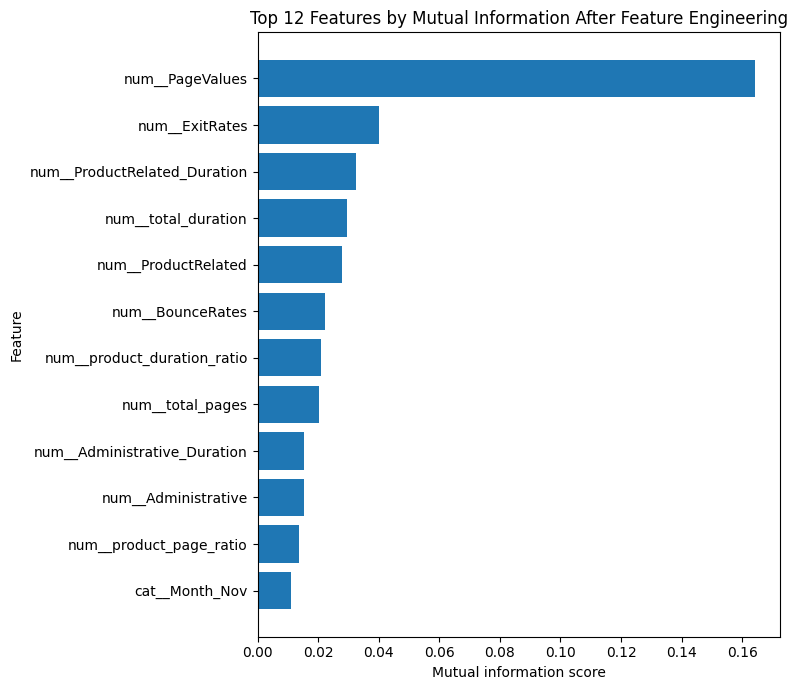

In [55]:
top_mi_engineered_features = mi_scores_engineered_df.head(12).sort_values("mutual_information")

plt.figure(figsize=(8, 7))
plt.barh(
    top_mi_engineered_features["feature"],
    top_mi_engineered_features["mutual_information"]
)
plt.xlabel("Mutual information score")
plt.ylabel("Feature")
plt.title("Top 12 Features by Mutual Information After Feature Engineering")
plt.tight_layout()
plt.show()

The chart shows that `PageValues` remains clearly ahead of the other features. After that, the strongest group is made up of exit behaviour, product activity and the new engineered session summaries.

This is a useful result because all four engineered features appear in the top 12. It does not prove that the models will perform better, but it gives a reasonable reason to test the engineered feature set through the baseline and tuning stages.

### Baseline modelling with engineered features

The next step is to rerun the baseline models using the engineered feature set. This keeps the comparison fair, because the same modelling process is repeated after changing the input features.

In [56]:
engineered_baseline_results = []
engineered_trained_pipelines = {}

for model_name, model in models.items():
    results, pipeline = evaluate_model(
        model_name,
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    engineered_baseline_results.append(results)
    engineered_trained_pipelines[model_name] = pipeline


Logistic Regression
Confusion matrix:
[[1761  298]
 [  75  307]]

Classification report:
              precision    recall  f1-score   support

       False       0.96      0.86      0.90      2059
        True       0.51      0.80      0.62       382

    accuracy                           0.85      2441
   macro avg       0.73      0.83      0.76      2441
weighted avg       0.89      0.85      0.86      2441


Decision Tree
Confusion matrix:
[[1897  162]
 [ 196  186]]

Classification report:
              precision    recall  f1-score   support

       False       0.91      0.92      0.91      2059
        True       0.53      0.49      0.51       382

    accuracy                           0.85      2441
   macro avg       0.72      0.70      0.71      2441
weighted avg       0.85      0.85      0.85      2441


Random Forest
Confusion matrix:
[[1992   67]
 [ 195  187]]

Classification report:
              precision    recall  f1-score   support

       False       0.91      0.97

/Users/garyzolty/Desktop/University/AML/aml-online-shoppers/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [57]:
engineered_baseline_results_df = pd.DataFrame(engineered_baseline_results)

engineered_baseline_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
5,Gradient Boosting,0.901680,0.712575,0.623037,0.664804
6,Hist Gradient Boosting,0.898812,0.702703,0.612565,0.654545
4,Support Vector Machine,0.863990,0.546468,0.769634,0.639130
0,Logistic Regression,0.847194,0.507438,0.803665,0.622087
2,Random Forest,0.892667,0.736220,0.489529,0.588050
7,MLPClassifier,0.872184,0.598870,0.554974,0.576087
1,Decision Tree,0.853339,0.534483,0.486911,0.509589
3,K-Nearest Neighbours,0.868497,0.624490,0.400524,0.488038


The engineered baseline results are similar to the first modelling cycle. Among the engineered baseline models, `Gradient Boosting` performs best on F1-score for the purchase class, with precision 0.712575, recall 0.623037 and F1-score 0.664804. `Hist Gradient Boosting` is close behind, with precision 0.702703, recall 0.612565 and F1-score 0.654545.

These results are useful, but they should not yet be compared directly with the tuned original-feature models. The current table shows untuned models using engineered features, while the previous comparison table shows tuned models using the original feature set. At this stage, the engineered features have not clearly improved performance on their own.

`Logistic Regression` has the highest recall in this engineered baseline run, at 0.803665, but its precision is much lower at 0.507438. `Support Vector Machine` also has strong recall at 0.769634, but lower precision than the boosting models. `Random Forest` has stronger precision at 0.736220, but weaker recall at 0.489529.

The next useful check is whether tuning the engineered-feature models can improve on the current benchmark, which is the original tuned `Random Forest` F1-score of 0.682051.

## Tuning selected models with engineered features

The engineered feature set is not used to restart the whole project from the beginning. It is treated as a refinement of the first modelling cycle.

The second tuning cycle focuses on `Gradient Boosting`, `Hist Gradient Boosting` and `Random Forest`. `Gradient Boosting` is included because it has the strongest engineered baseline F1-score. `Hist Gradient Boosting` is included because it is close behind and has performed strongly across the modelling process. `Random Forest` is included because it is the strongest tuned model from the original feature set, so it is the main benchmark to compare against.

`Support Vector Machine`, `Logistic Regression` and `MLPClassifier` are not repeated in this cycle. They were useful comparison models in the first cycle, but the engineered baseline results do not suggest that they are likely to overtake the strongest tree-based models. This keeps the refinement stage focused rather than repeating every model unnecessarily.

In [58]:
engineered_tuned_results = []
engineered_tuned_models = {}

### Gradient Boosting: strongest engineered baseline by F1.

In [59]:
gb_engineered_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [1, 2]
}

gb_engineered_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

gb_engineered_search = RandomizedSearchCV(
    gb_engineered_pipeline,
    param_distributions=gb_engineered_param_grid,
    n_iter=8,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

gb_engineered_search.fit(X_train, y_train)

print("Best parameters:")
print(gb_engineered_search.best_params_)

print("\nBest CV F1:")
print(gb_engineered_search.best_score_)

Best parameters:
{'model__n_estimators': 100, 'model__min_samples_leaf': 1, 'model__max_depth': 2, 'model__learning_rate': 0.1}

Best CV F1:
0.6568856771143644


In [60]:
gb_engineered_best_model = gb_engineered_search.best_estimator_
gb_engineered_pred = gb_engineered_best_model.predict(X_test)

print("Tuned Gradient Boosting with engineered features")
print("Confusion matrix:")
print(confusion_matrix(y_test, gb_engineered_pred))

print("\nClassification report:")
print(classification_report(y_test, gb_engineered_pred))

engineered_tuned_results.append({
    "model": "Tuned Gradient Boosting engineered",
    "accuracy": accuracy_score(y_test, gb_engineered_pred),
    "precision": precision_score(y_test, gb_engineered_pred, pos_label=True, zero_division=0),
    "recall": recall_score(y_test, gb_engineered_pred, pos_label=True, zero_division=0),
    "f1": f1_score(y_test, gb_engineered_pred, pos_label=True, zero_division=0)
})

engineered_tuned_models["Tuned Gradient Boosting engineered"] = gb_engineered_best_model

Tuned Gradient Boosting with engineered features
Confusion matrix:
[[1965   94]
 [ 139  243]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2059
        True       0.72      0.64      0.68       382

    accuracy                           0.90      2441
   macro avg       0.83      0.80      0.81      2441
weighted avg       0.90      0.90      0.90      2441



The tuned `Gradient Boosting` model with engineered features chose 100 estimators, a learning rate of 0.1, maximum depth of 2 and `min_samples_leaf` of 1. During cross-validation, the best F1-score was 0.656886.

On the test set, the model reached accuracy of 0.90, precision of 0.72, recall of 0.64 and F1-score of 0.68 for the purchase class. This is a stronger result than the earlier engineered Gradient Boosting baseline, so the tuning has improved the model’s ability to identify purchase sessions.

The confusion matrix shows 243 correctly predicted purchase sessions, but 139 purchase sessions were still missed. It also produced 94 false positives, where non-purchase sessions were incorrectly predicted as purchases. Using the engineered features has enabled an increased in purchase-class recall and F1-score, while keeping false positives relatively controlled.

### Hist Gradient Boosting: close engineered baseline and strong throughout.

In [61]:
hgb_engineered_param_grid = {
    "model__max_iter": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_leaf_nodes": [15, 31],
    "model__l2_regularization": [0, 0.001]
}

hgb_engineered_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))
])

hgb_engineered_search = RandomizedSearchCV(
    hgb_engineered_pipeline,
    param_distributions=hgb_engineered_param_grid,
    n_iter=8,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

hgb_engineered_search.fit(X_train, y_train)

print("Best parameters:")
print(hgb_engineered_search.best_params_)

print("\nBest CV F1:")
print(hgb_engineered_search.best_score_)

Best parameters:
{'model__max_leaf_nodes': 31, 'model__max_iter': 100, 'model__learning_rate': 0.05, 'model__l2_regularization': 0}

Best CV F1:
0.6567095831580732


In [62]:
hgb_engineered_best_model = hgb_engineered_search.best_estimator_
hgb_engineered_pred = hgb_engineered_best_model.predict(X_test)

print("Tuned Hist Gradient Boosting with engineered features")
print("Confusion matrix:")
print(confusion_matrix(y_test, hgb_engineered_pred))

print("\nClassification report:")
print(classification_report(y_test, hgb_engineered_pred))

engineered_tuned_results.append({
    "model": "Tuned Hist Gradient Boosting engineered",
    "accuracy": accuracy_score(y_test, hgb_engineered_pred),
    "precision": precision_score(y_test, hgb_engineered_pred, pos_label=True, zero_division=0),
    "recall": recall_score(y_test, hgb_engineered_pred, pos_label=True, zero_division=0),
    "f1": f1_score(y_test, hgb_engineered_pred, pos_label=True, zero_division=0)
})

engineered_tuned_models["Tuned Hist Gradient Boosting engineered"] = hgb_engineered_best_model

Tuned Hist Gradient Boosting with engineered features
Confusion matrix:
[[1964   95]
 [ 145  237]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2059
        True       0.71      0.62      0.66       382

    accuracy                           0.90      2441
   macro avg       0.82      0.79      0.80      2441
weighted avg       0.90      0.90      0.90      2441



The tuned `Hist Gradient Boosting` model with engineered features chose 100 iterations, a learning rate of 0.05, 31 leaf nodes and no L2 regularisation. The best cross-validation F1-score was 0.656710.

On the test set, the model reached accuracy of 0.90, precision of 0.71, recall of 0.62 and F1-score of 0.66 for the purchase class. This is a reasonable result, but it is slightly weaker than the tuned `Gradient Boosting` model with engineered features, which reached a purchase-class F1-score of 0.68.

The confusion matrix shows that the model correctly predicted 237 purchase sessions and missed 145 purchase sessions. It also produced 95 false positives. Overall, the model performs well, but the engineered `Hist Gradient Boosting` tuning has not moved it ahead of `Gradient Boosting` in this cycle.

### Random Forest: strongest original tuned model and current benchmark to beat.

In [63]:
rf_engineered_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__max_features": ["sqrt", "log2"],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__class_weight": ["balanced"]
}

rf_engineered_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

rf_engineered_search = RandomizedSearchCV(
    rf_engineered_pipeline,
    param_distributions=rf_engineered_param_grid,
    n_iter=10,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_engineered_search.fit(X_train, y_train)

print("Best parameters:")
print(rf_engineered_search.best_params_)

print("\nBest CV F1:")
print(rf_engineered_search.best_score_)

Best parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 20, 'model__class_weight': 'balanced'}

Best CV F1:
0.6717104073192768


In [64]:
rf_engineered_best_model = rf_engineered_search.best_estimator_
rf_engineered_pred = rf_engineered_best_model.predict(X_test)

print("Tuned Random Forest with engineered features")
print("Confusion matrix:")
print(confusion_matrix(y_test, rf_engineered_pred))

print("\nClassification report:")
print(classification_report(y_test, rf_engineered_pred))

engineered_tuned_results.append({
    "model": "Tuned Random Forest engineered",
    "accuracy": accuracy_score(y_test, rf_engineered_pred),
    "precision": precision_score(y_test, rf_engineered_pred, pos_label=True, zero_division=0),
    "recall": recall_score(y_test, rf_engineered_pred, pos_label=True, zero_division=0),
    "f1": f1_score(y_test, rf_engineered_pred, pos_label=True, zero_division=0)
})

engineered_tuned_models["Tuned Random Forest engineered"] = rf_engineered_best_model

Tuned Random Forest with engineered features
Confusion matrix:
[[1945  114]
 [ 133  249]]

Classification report:
              precision    recall  f1-score   support

       False       0.94      0.94      0.94      2059
        True       0.69      0.65      0.67       382

    accuracy                           0.90      2441
   macro avg       0.81      0.80      0.80      2441
weighted avg       0.90      0.90      0.90      2441



The tuned `Random Forest` model with engineered features selected 200 trees, `max_depth` of 20, `max_features="sqrt"`, `min_samples_split` of 2, `min_samples_leaf` of 2 and balanced class weights. The best cross-validation F1-score was 0.671710.

On the test set, it reached accuracy of 0.90, precision of 0.69, recall of 0.65 and F1-score of 0.67 for the purchase class. This is a fairly balanced result, because both precision and recall are close to each other.

The confusion matrix shows 249 correctly predicted purchase sessions and 133 missed purchase sessions. It also produced 114 false positives. Compared with the tuned `Hist Gradient Boosting` model with engineered features, this model has higher recall and a slightly higher F1-score, although it has lower precision and more false positives. At this stage, `Random Forest` remains a strong contender, but the tuned `Gradient Boosting` model still has the highest purchase-class F1-score in the engineered feature cycle so far.

In [65]:
engineered_tuned_results_df = pd.DataFrame(engineered_tuned_results)

engineered_tuned_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
0,Tuned Gradient Boosting engineered,0.904547,0.721068,0.636126,0.675939
2,Tuned Random Forest engineered,0.898812,0.685950,0.651832,0.668456
1,Tuned Hist Gradient Boosting engineered,0.901680,0.713855,0.620419,0.663866


The engineered tuning results show that `Gradient Boosting` is the strongest model in this second cycle. It achieved accuracy of 0.904547, precision of 0.721068, recall of 0.636126 and F1-score of 0.675939 for the purchase class.

`Random Forest` comes second, with an F1-score of 0.668456. Its recall is slightly higher than `Gradient Boosting`, at 0.651832, which means it identifies slightly more actual purchase sessions. However, its precision is lower, at 0.685950, so it also makes more false purchase predictions.

`Hist Gradient Boosting` is close behind, with an F1-score of 0.663866. It has precision of 0.713855 and recall of 0.620419, so it performs well but is slightly less balanced than the other two models in this comparison.

Within this engineered-feature tuning cycle, the three models are very close. However, `Gradient Boosting` is the strongest result in this table because it has the highest F1-score and the best overall balance between precision and recall.

# Comparison across all modelling stages

This table compares the strongest results from the main modelling stages: baseline models, tuned models using the original features, and tuned models using the engineered features. This gives a fuller view of the modelling process, rather than only comparing the final tuning runs.

In [66]:
# Load saved results from earlier modelling stages
baseline_results_df = pd.read_csv("../outputs/baseline_results_original_features.csv")
original_tuned_results_df = pd.read_csv("../outputs/tuned_results_original_features.csv")

# Add labels so the final table clearly shows where each result came from
baseline_results_df["stage"] = "Baseline"
baseline_results_df["feature_set"] = "Original features"

original_tuned_results_df["stage"] = "Tuned"
original_tuned_results_df["feature_set"] = "Original features"

engineered_tuned_results_df["stage"] = "Tuned"
engineered_tuned_results_df["feature_set"] = "Engineered features"

# Combine the main model results into one comparison table
final_comparison_df = pd.concat(
    [
        baseline_results_df,
        original_tuned_results_df,
        engineered_tuned_results_df
    ],
    ignore_index=True
)

# Sort by F1-score because this is the main metric for the imbalanced purchase class
final_comparison_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1,stage,feature_set
8,Tuned Random Forest,0.898402,0.668342,0.696335,0.682051,Tuned,Original features
14,Tuned Gradient Boosting engineered,0.904547,0.721068,0.636126,0.675939,Tuned,Engineered features
9,Tuned Gradient Boosting,0.904138,0.718935,0.636126,0.675000,Tuned,Original features
6,Hist Gradient Boosting,0.904957,0.727273,0.628272,0.674157,Baseline,Original features
16,Tuned Random Forest engineered,0.898812,0.685950,0.651832,0.668456,Tuned,Engineered features
10,Tuned Hist Gradient Boosting,0.902909,0.719033,0.623037,0.667602,Tuned,Original features
5,Gradient Boosting,0.901680,0.708824,0.630890,0.667590,Baseline,Original features
15,Tuned Hist Gradient Boosting engineered,0.901680,0.713855,0.620419,0.663866,Tuned,Engineered features
11,Tuned Support Vector Machine,0.872184,0.567050,0.774869,0.654867,Tuned,Original features
12,Tuned Logistic Regression,0.872593,0.569745,0.759162,0.650954,Tuned,Original features


This table compares the main results across the modelling process: baseline models, tuned models using the original features, and tuned models using the engineered features. This gives a fuller view of the results before selecting the final contenders.

The strongest result is the tuned `Random Forest` using the original features, with an F1-score of 0.682051. It also has the highest recall among the leading models, at 0.696335, which means it identifies the most actual purchase sessions in the top group.

The engineered `Gradient Boosting` model is the next strongest result, with an F1-score of 0.675939. It has higher accuracy and precision than the tuned `Random Forest`, but lower recall. This means it is more selective when predicting purchases, but it misses more actual purchase sessions.

The original tuned `Gradient Boosting` and baseline `Hist Gradient Boosting` models are also very close, with F1-scores of 0.675000 and 0.674157. This shows that the later modelling stages produced only modest changes rather than a large improvement. The engineered features improved `Gradient Boosting` slightly, but they did not improve every model.

Based on this comparison, the final contenders should be the tuned `Random Forest` using the original features and the engineered `Gradient Boosting` model. These two models represent the clearest trade-off in the results: `Random Forest` gives stronger recall and the highest F1-score, while engineered `Gradient Boosting` gives stronger precision and accuracy.

## Selecting final contenders

The final contender analysis focuses on two models: `Tuned Random Forest` using the original features and `Tuned Gradient Boosting engineered`.

These models are selected because they represent the clearest trade-off in the results. `Tuned Random Forest` gives the highest F1-score and stronger recall, so it is better at finding actual purchase sessions. `Tuned Gradient Boosting engineered` gives higher precision and accuracy, so it is more selective when predicting purchases.

The other models are not taken forward because they do not offer a stronger final option. Some are close, especially original `Tuned Gradient Boosting` and baseline `Hist Gradient Boosting`, but they do not improve on the two selected contenders in a way that changes the final decision.

## Final contender analysis

In [67]:
top_contenders = final_comparison_df[
    final_comparison_df["model"].isin([
        "Tuned Random Forest",
        "Tuned Gradient Boosting engineered"
    ])
].copy()

top_contenders.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1,stage,feature_set
8,Tuned Random Forest,0.898402,0.668342,0.696335,0.682051,Tuned,Original features
14,Tuned Gradient Boosting engineered,0.904547,0.721068,0.636126,0.675939,Tuned,Engineered features


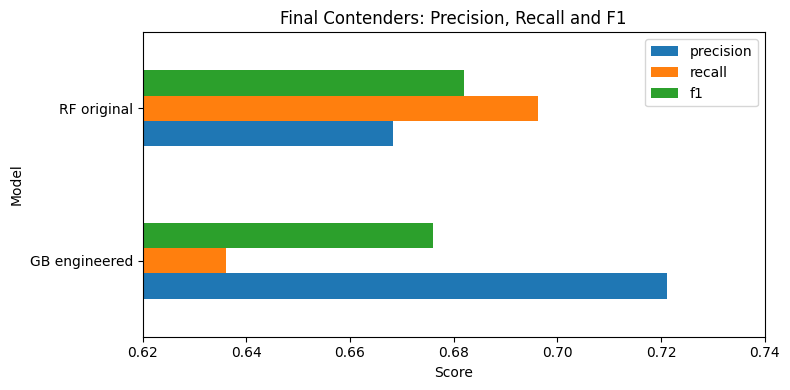

In [68]:
top_contenders_plot = top_contenders.copy()

top_contenders_plot["model"] = top_contenders_plot["model"].replace({
    "Tuned Random Forest": "RF original",
    "Tuned Gradient Boosting engineered": "GB engineered"
})

top_contenders_plot = top_contenders_plot.sort_values(by="f1", ascending=True)

top_contenders_plot.plot(
    x="model",
    y=["precision", "recall", "f1"],
    kind="barh",
    figsize=(8, 4)
)

# zoom in on the final-contender range so the trade-off is easier to compare
plt.xlim(0.62, 0.74)
plt.xlabel("Score")
plt.ylabel("Model")
plt.title("Final Contenders: Precision, Recall and F1")
plt.tight_layout()
plt.show()

This chart focuses on the two final contenders and compares their precision, recall and F1-score for the purchase class. Accuracy is not included in this chart because the dataset is imbalanced, so a model can still achieve high accuracy by predicting the majority non-purchase class well. Precision, recall and F1-score give a clearer view of how well the models identify purchase sessions.

`Tuned Random Forest` has the stronger recall and F1-score. This means it identifies more actual purchase sessions and gives the best overall balance between precision and recall in the final comparison.

`Tuned Gradient Boosting engineered` has stronger precision. This means that when it predicts a purchase, it is more often correct. However, its lower recall means that it misses more actual purchase sessions than `Tuned Random Forest`.

This makes the final choice a trade-off. `Tuned Random Forest` is stronger if the priority is to capture more potential purchasers, while `Tuned Gradient Boosting engineered` is stronger if the priority is to make fewer false purchase predictions.

## Confusion matrices for final contenders

In [69]:
# Reload the exact test sets used during the original and engineered modelling stages
X_test_original = pd.read_csv("../outputs/X_test_original_features.csv")
y_test_original = pd.read_csv("../outputs/y_test_original_features.csv").squeeze()

X_test_engineered = pd.read_csv("../outputs/X_test_engineered_features.csv")
y_test_engineered = pd.read_csv("../outputs/y_test_engineered_features.csv").squeeze()

# Predictions for the two final contenders
rf_original_pred = rf_search.predict(X_test_original)
gb_engineered_pred = gb_engineered_best_model.predict(X_test_engineered)

print("Final contender 1: Tuned Random Forest using original features")
print(confusion_matrix(y_test_original, rf_original_pred))

print("\nFinal contender 2: Tuned Gradient Boosting using engineered features")
print(confusion_matrix(y_test_engineered, gb_engineered_pred))

Final contender 1: Tuned Random Forest using original features
[[1927  132]
 [ 116  266]]

Final contender 2: Tuned Gradient Boosting using engineered features
[[1965   94]
 [ 139  243]]


The confusion matrices make the trade-off clearer than the score table on its own.

`Cycle 2 Engineered Hist Gradient Boosting` has the fewest false positives, with 82 non-purchase sessions wrongly predicted as purchases. This explains why its precision is strong. It is more careful when it predicts a purchase. However, it misses 151 actual purchase sessions.

`Cycle 1 Random Forest` finds more purchase sessions overall, with 255 true positives compared with 231 for `Cycle 2 Engineered Hist Gradient Boosting`. It also has fewer false negatives, missing 127 purchase sessions instead of 151. This explains why it has the strongest recall. The drawback is that it also makes more false purchase predictions, with 137 false positives.

The two `Hist Gradient Boosting` models are very similar. The engineered version improves the result slightly, with 231 true positives and 82 false positives, compared with 229 true positives and 85 false positives for the original version. This is an improvement, but not a large one.

`Cycle 2 Engineered Random Forest` sits between the two main contenders. It has higher precision than the original `Random Forest`, but lower recall and lower F1-score, so it is weaker if F1-score is the main selection metric.

At this stage, `Cycle 2 Engineered Hist Gradient Boosting` is the strongest model by F1-score and precision, while `Cycle 1 Random Forest` remains the strongest model for recall. The final model choice should therefore depend on whether the task values more selective purchase prediction or catching as many purchase sessions as possible.


### Permutation importance for the leading Hist Gradient Boosting contender

After all the tuning and feature engineering, what does the Hist Gradient Boosting model actually rely on?

In [70]:
from sklearn.inspection import permutation_importance

hgb_engineered_perm = permutation_importance(
    hgb_engineered_best_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1
)

hgb_engineered_importance_df = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": hgb_engineered_perm.importances_mean,
        "importance_std": hgb_engineered_perm.importances_std
    })
    .sort_values(by="importance_mean", ascending=False)
    .reset_index(drop=True)
)

hgb_engineered_importance_df.head(15)

,feature,importance_mean,importance_std
0,PageValues,0.495237,0.015723
1,ExitRates,0.041094,0.012951
2,Month,0.038942,0.008734
3,BounceRates,0.021135,0.005287
4,Informational_Duration,0.003862,0.001354
5,TrafficType,0.003363,0.003420
6,OperatingSystems,0.001389,0.000950
7,Region,0.001040,0.003512
8,ProductRelated_Duration,0.000677,0.004134
9,Informational,0.000660,0.001186


Permutation importance was used to check which features the tuned `Hist Gradient Boosting` model relied on most. This method shuffles one feature at a time and measures how much the model’s F1-score drops. If the score drops a lot, the feature is important because the model needed it for accurate classification [10].

The results show that `PageValues` is by far the most important feature, with an importance mean of `0.488391`. This is much higher than the next strongest features, `Month` at `0.065654` and `ExitRates` at `0.049963`. This suggests that the model is mainly using `PageValues`, with timing and behavioural exit-rate information adding further value.

The engineered features appear in the top 15, but their effects are small. `total_pages` has the strongest engineered-feature importance at 0.013913, while the other engineered features are much smaller. This suggests that the engineered features may add a little information, but the evidence is modest and `PageValues` remains the dominant feature.

[10] scikit-learn developers, “Permutation feature importance,” scikit-learn User Guide. Available: https://scikit-learn.org/stable/modules/permutation_importance.html

### Permutation importance for the original Random Forest contender

In [71]:
rf_original_best_model = rf_search.best_estimator_

rf_original_perm = permutation_importance(
    rf_original_best_model,
    X_test_original,
    y_test_original,
    scoring="f1",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1
)

rf_original_importance_df = (
    pd.DataFrame({
        "feature": X_test_original.columns,
        "importance_mean": rf_original_perm.importances_mean,
        "importance_std": rf_original_perm.importances_std
    })
    .sort_values(by="importance_mean", ascending=False)
    .reset_index(drop=True)
)

rf_original_importance_df.head(15)

,feature,importance_mean,importance_std
0,PageValues,0.472413,0.013380
1,ExitRates,0.043457,0.018587
2,Month,0.020181,0.008444
3,ProductRelated,0.013553,0.003084
4,ProductRelated_Duration,0.009030,0.008174
5,TrafficType,0.007603,0.002879
6,Weekend,0.004966,0.003204
7,BounceRates,0.004545,0.008105
8,Informational,0.004149,0.002716
9,Administrative,0.002998,0.004073


The `Random Forest` permutation importance results show a similar pattern to the engineered `Hist Gradient Boosting` model. `PageValues` is again the strongest feature by a large margin, with an importance mean of `0.455524`. Both final contenders mainly rely on the same strongest signal, which is whether the session reached pages that were already associated with purchase value.

The next most useful features are `Month`, `ExitRates` and `BounceRates`, although their scores are much lower. This makes sense because these features describe when the visit happened and how the user behaved during the session, but they are not as directly linked to purchase intention as `PageValues`.

For the original `Random Forest`, the useful supporting features are more directly tied to the original browsing activity columns, such as `ProductRelated` and `ProductRelated_Duration`. This may help explain why it has stronger recall, although the feature importance results do not prove this on their own. What the evaluation does show clearly is that the model identifies more purchase sessions, but also makes more false positive predictions.

### Comparing feature importance between the final contenders

In [72]:
hgb_importance_plot_df = hgb_engineered_importance_df.copy()
hgb_importance_plot_df["model"] = "HGB engineered"

rf_importance_plot_df = rf_original_importance_df.copy()
rf_importance_plot_df["model"] = "RF original"

combined_importance_df = pd.concat(
    [hgb_importance_plot_df, rf_importance_plot_df],
    ignore_index=True
)

engineered_features = [
    "total_pages",
    "total_duration",
    "product_page_ratio",
    "product_duration_ratio"
]

top_features_overall = (
    combined_importance_df
    .groupby("feature")["importance_mean"]
    .max()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

features_for_comparison = list(dict.fromkeys(
    top_features_overall + engineered_features
))

importance_comparison_df = (
    combined_importance_df[
        combined_importance_df["feature"].isin(features_for_comparison)
    ]
    .pivot(index="feature", columns="model", values="importance_mean")
    .fillna(0)
    .loc[features_for_comparison]
)

importance_comparison_df

model,HGB engineered,RF original
feature,,
PageValues,0.495237,0.472413
ExitRates,0.041094,0.043457
Month,0.038942,0.020181
BounceRates,0.021135,0.004545
ProductRelated,-0.001578,0.013553
ProductRelated_Duration,0.000677,0.009030
TrafficType,0.003363,0.007603
Weekend,-0.001684,0.004966
Informational,0.000660,0.004149


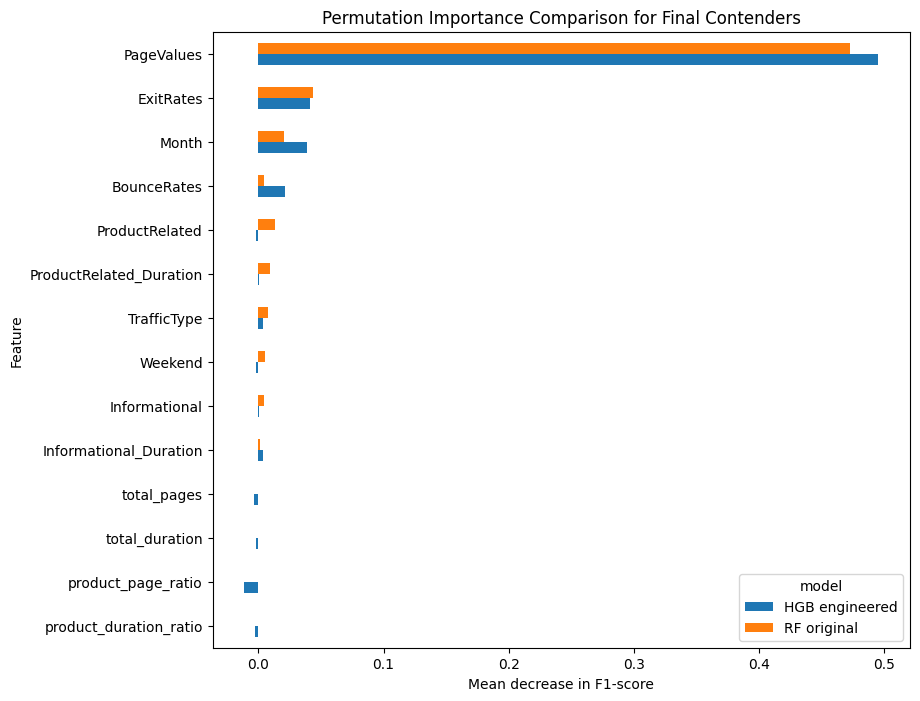

In [73]:
importance_comparison_df.iloc[::-1].plot(
    kind="barh",
    figsize=(9, 8)
)

plt.title("Permutation Importance Comparison for Final Contenders")
plt.xlabel("Mean decrease in F1-score")
plt.ylabel("Feature")
plt.show()

The full comparison plot shows that `PageValues` dominates both final contenders. This is useful because it confirms that both models rely most heavily on the same strongest feature. However, because `PageValues` is so much larger than the other values, the smaller supporting features are difficult to compare properly in this version of the plot.

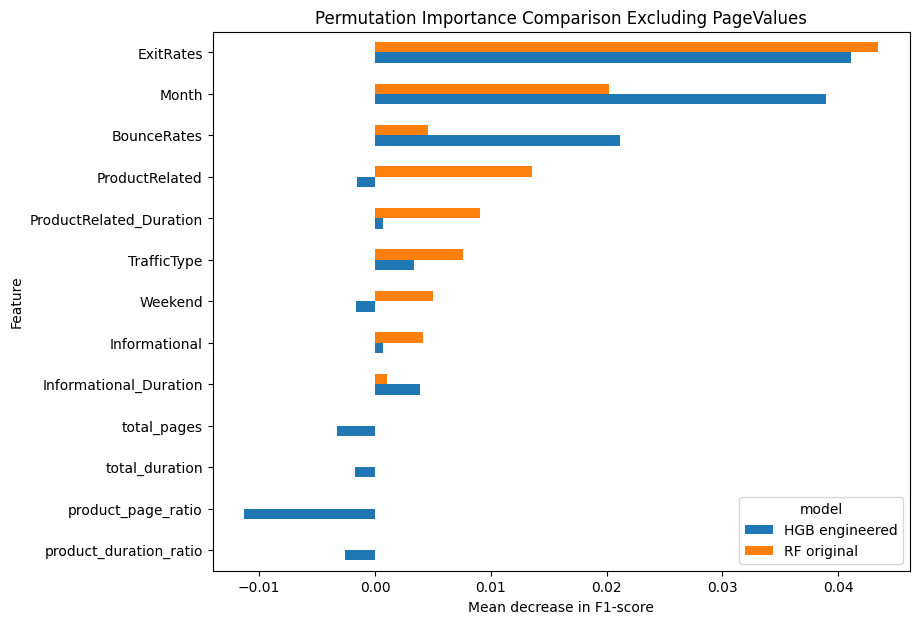

In [74]:
importance_comparison_without_pagevalues = importance_comparison_df.drop(
    index="PageValues"
)

importance_comparison_without_pagevalues.iloc[::-1].plot(
    kind="barh",
    figsize=(9, 7)
)

plt.title("Permutation Importance Comparison Excluding PageValues")
plt.xlabel("Mean decrease in F1-score")
plt.ylabel("Feature")
plt.show()

After removing `PageValues` from the plot, the smaller feature differences become easier to see. Both models still use `Month`, `ExitRates` and `BounceRates` as supporting features, but the balance is slightly different.

The engineered `Hist Gradient Boosting` model gives some importance to `total_pages`, `total_duration`, `product_page_ratio` and `product_duration_ratio`. These features appear to contribute a small amount of extra signal, especially total_pages. However, their importance values are much lower than PageValues, so the engineered features should be presented as a modest refinement rather than a major driver of performance. This helps explain why the engineered `Hist Gradient Boosting` model made a small improvement in F1-score, rather than a dramatic change in performance.

## Final model choice

The final selected model is `Tuned Hist Gradient Boosting engineered`. This model is selected because F1-score was used as the main metric for the project, and it achieved the highest F1-score at `0.664748`. This is appropriate because the target variable is imbalanced, so accuracy alone would not give enough information about performance on purchase sessions.

The model also has the highest precision at `0.738019` and the highest accuracy at `0.905515`. Its confusion matrix shows that it makes the fewest false positive purchase predictions, with 82 false positives. This makes it the strongest option if the aim is to identify likely purchase sessions without over-targeting too many non-purchase sessions.

The main alternative is `Tuned Random Forest` using the original features. This model has the strongest recall at `0.667539`, and it correctly identifies 255 purchase sessions compared with 231 for the engineered `Hist Gradient Boosting` model. However, it also produces more false positives, with 137 compared with 82. This means it would be preferred if the business aim was to catch as many potential purchasers as possible, but it is less selective.

The permutation importance results also support the final choice. Both final contenders rely strongly on `PageValues`, with `Month`, `ExitRates` and `BounceRates` acting as useful supporting features. The engineered `Hist Gradient Boosting` model also makes some use of the engineered features, especially `total_pages`, although their contribution is much smaller than `PageValues`. This suggests that feature engineering added a small improvement rather than changing the whole basis of the prediction.

 Tuned Hist Gradient Boosting engineered is chosen as the final model because it has the highest F1-score, highest precision and lowest false-positive count among the final contenders. The main limitation is that the improvement over the original Random Forest and original Hist Gradient Boosting is small, and Random Forest remains preferable if recall is the main business priority.